<a href="https://colab.research.google.com/github/MarkLee1435/Soft-Robotics-263F/blob/main/Soft_Jellyfish_2D_v_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # Only for iPython
from matplotlib.animation import FuncAnimation

#Helper function

In [ ]:
def crossMat(a):
    """
    Returns the cross product matrix of vector 'a'.

    Parameters:
    a : np.ndarray
        A 3-element array representing a vector.

    Returns:
    A : np.ndarray
        The cross product matrix corresponding to vector 'a'.
    """
    A = np.array([[0, -a[2], a[1]],
                  [a[2], 0, -a[0]],
                  [-a[1], a[0], 0]])

    return A

#Gradient and Hessian of elastic energies

In [ ]:
def gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the derivative of bending energy E_k^b with respect to
    x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dF : np.ndarray
        Derivative of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0.0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Gradient of bending energy
    dkappa = kappa1 - kappaBar
    dF = gradKappa * EI * dkappa / l_k

    return dF

In [ ]:
def hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the Hessian (second derivative) of bending energy E_k^b
    with respect to x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dJ : np.ndarray
        Hessian of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Compute the Hessian (second derivative of kappa)
    DDkappa1 = np.zeros((6, 6))

    norm2_e = norm_e**2
    norm2_f = norm_f**2

    Id3 = np.eye(3)

    # Helper matrices for second derivatives
    tt_o_tt = np.outer(tilde_t, tilde_t)
    tmp = np.cross(tf, tilde_d2)
    tf_c_d2t_o_tt = np.outer(tmp, tilde_t)
    kb_o_d2e = np.outer(kb, m2e)

    D2kappa1De2 = (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt - tf_c_d2t_o_tt.T) / norm2_e - \
                  kappa1 / (chi * norm2_e) * (Id3 - np.outer(te, te)) + \
                  (kb_o_d2e + kb_o_d2e.T) / (4 * norm2_e)

    tmp = np.cross(te, tilde_d2)
    te_c_d2t_o_tt = np.outer(tmp, tilde_t)
    tt_o_te_c_d2t = te_c_d2t_o_tt.T
    kb_o_d2f = np.outer(kb, m2f)

    D2kappa1Df2 = (2 * kappa1 * tt_o_tt + te_c_d2t_o_tt + te_c_d2t_o_tt.T) / norm2_f - \
                  kappa1 / (chi * norm2_f) * (Id3 - np.outer(tf, tf)) + \
                  (kb_o_d2f + kb_o_d2f.T) / (4 * norm2_f)
    D2kappa1DeDf = -kappa1 / (chi * norm_e * norm_f) * (Id3 + np.outer(te, tf)) \
                  + 1.0 / (norm_e * norm_f) * (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt + \
                  tt_o_te_c_d2t - crossMat(tilde_d2))
    D2kappa1DfDe = D2kappa1DeDf.T

    # Populate the Hessian of kappa
    DDkappa1[0:2, 0:2] = D2kappa1De2[0:2, 0:2]
    DDkappa1[0:2, 2:4] = -D2kappa1De2[0:2, 0:2] + D2kappa1DeDf[0:2, 0:2]
    DDkappa1[0:2, 4:6] = -D2kappa1DeDf[0:2, 0:2]
    DDkappa1[2:4, 0:2] = -D2kappa1De2[0:2, 0:2] + D2kappa1DfDe[0:2, 0:2]
    DDkappa1[2:4, 2:4] = D2kappa1De2[0:2, 0:2] - D2kappa1DeDf[0:2, 0:2] - \
                         D2kappa1DfDe[0:2, 0:2] + D2kappa1Df2[0:2, 0:2]
    DDkappa1[2:4, 4:6] = D2kappa1DeDf[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 0:2] = -D2kappa1DfDe[0:2, 0:2]
    DDkappa1[4:6, 2:4] = D2kappa1DfDe[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 4:6] = D2kappa1Df2[0:2, 0:2]

    # Hessian of bending energy
    dkappa = kappa1 - kappaBar
    dJ = 1.0 / l_k * EI * np.outer(gradKappa, gradKappa)
    dJ += 1.0 / l_k * dkappa * EI * DDkappa1

    return dJ

In [ ]:
def gradEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * EA * l_k * F  # Scale by EA and l_k

    return F

In [ ]:
def hessEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * EA * l_k

    return J

# Functions to create elastic force vector and its Hessian

In [ ]:
def getFs(q, EA, deltaL):
  # q - DOF vector of size N
  # EA - stretching stiffness
  # deltaL - undeformed reference length (assume to be a scalar for this simple example)
  # Output:
  # Fs - a vector (negative gradient of elastic stretching force)
  # Js - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fs = np.zeros(ndof) # stretching force
  Js = np.zeros((ndof, ndof))

  for k in range(0, N-1):
      # May need to modify if network of beams
      # k-th stretching spring (USE A LOOP for the general case
      xkm1 = q[2*k] # x coordinate of the first node
      ykm1 = q[2*k+1] # y coordinate of the first node
      xk = q[2*k+2] # x coordinate of the second node
      yk = q[2*k+3] # y coordinate of the second node
      ind = np.arange(2*k, 2*k+4) # 0, 1, 2, 3 for k = 0
      gradEnergy = gradEs(xkm1, ykm1, xk, yk, deltaL[k], EA)
      hessEnergy = hessEs(xkm1, ykm1, xk, yk, deltaL[k], EA)

      Fs[ind] -= gradEnergy # force = - gradient of energy. Fs is the stretching force
      Js[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:4

  return Fs, Js

In [ ]:
def getFb(q, EI, deltaL, kappas):
  # q - DOF vector of size N
  # EI - bending stiffness
  # deltaL - undeformed Voronoi length (assume to be a scalar for this simple example)
  # Output:
  # Fb - a vector (negative gradient of elastic stretching force)
  # Jb - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fb = np.zeros(ndof) # bending force
  Jb = np.zeros((ndof, ndof))

  # First bending spring (USE A LOOP for the general case)
  for k in range(1, N-1):
    xkm1 = q[2*k-2] # x coordinate of the first node
    ykm1 = q[2*k-1] # y coordinate of the first node
    xk = q[2*k] # x coordinate of the second node
    yk = q[2*k+1] # y coordinate of the second node
    xkp1 = q[2*k+2] # x coordinate of the third node
    ykp1 = q[2*k+3] # y coordinate of the third node
    ind = np.arange(2*k-2, 2*k+4)
    gradEnergy = gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, kappas[k-1], (deltaL[k-1]+deltaL[k])/2, EI)
    hessEnergy = hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, kappas[k-1], (deltaL[k-1]+deltaL[k])/2, EI)

    Fb[ind] -= gradEnergy # force = - gradient of energy. Fb is the stretching force
    Jb[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:6

  return Fb, Jb

#Hydrodynamics

In [ ]:
def computeTangent(q):
  # q is the DOF vector of size 2*nv
  nv = len(q) // 2
  ne = nv - 1
  tangent = np.zeros((ne, 2))  # every edge has a tangent
  for c in range(ne):
    node0 = q[2*c:2*c+2]
    node1 = q[2*c+2:2*c+4]
    edge = node1 - node0
    tangent[c, :] = edge / np.linalg.norm(edge)
  return tangent

In [ ]:
def getF_lowRe(q, q_old, dt, Ct, Cp, deltaL, u_f=None):
    """
    Low Reynolds number hydrodynamic drag (Resistive Force Theory) for DER rods.

    q : new DOF
    dt : float
    Ct, Cp : RFT Coefficients
    deltaL : undeformed edge lengths
    u_f : array_like, shape (3,), optional

    Returns
    -------
    Fh : hydrodynamic force
    Jh : Jacobian of the hydrodynamic contribution w.r.t. q.
    """
    ndof = q.shape[0]
    nv = ndof // 2        # number of nodes
    ne = nv - 1           # number of edges

    voronoiRefLen = np.zeros(nv)  # find voronoi reference lengths from edge lengths
    voronoiRefLen[0] = deltaL[0]/2
    voronoiRefLen[-1] = deltaL[-1]/2
    for i in range(1,nv-1):
      voronoiRefLen[i] = (deltaL[i-1]+deltaL[i])/2

    if u_f is None:
        u_f = np.zeros(2)
    else:
        u_f = np.asarray(u_f, dtype=float)

    # Extract nodal positions at old and new times
    x_new = np.zeros((nv, 2))
    x_old = np.zeros((nv, 2))
    for k in range(nv):
        idx = 2 * k
        x_new[k, :] = q[idx:idx+2]
        x_old[k, :] = q_old[idx:idx+2]

    # Nodal velocities (backward Euler)
    u = (x_new - x_old) / dt

    # Edge tangents (new configuration)
    t_edge = computeTangent(q)

    # Nodal tangents (average of adjacent edges, normalized)
    t_node = np.zeros((nv, 2))
    # endpoints
    t_node[0] = t_edge[0]
    t_node[-1] = t_edge[-1]

    # interior nodes
    for k in range(1, nv-1):
      t_sum = t_edge[k-1] + t_edge[k]
      L = np.linalg.norm(t_sum)
      t_node[k] = t_sum / L

    # Allocate residual and Jacobian
    Fh = np.zeros(ndof)
    Jh = np.zeros((ndof, ndof))

    I2 = np.eye(2)

    for k in range(nv):
        # relative velocity
        u_rel = u[k] - u_f

        t = t_node[k]
        Pt = np.outer(t, t)
        Pn = I2 - Pt

        # RFT matrix at node k
        M = Ct * Pt + Ct * Pn

        lk = voronoiRefLen[k]

        # physical hydrodynamic drag force (2-vector)
        f_drag = -lk * (M @ u_rel)

        # Jacobian of physical drag wrt x_k(t_{j+1}):
        J_block = - (lk / dt) * M

        # Indices of translational DOFs of node k in q
        idx = np.array([2*k, 2*k+1])

        # Assemble
        Fh[idx] += f_drag
        Jh[np.ix_(idx, idx)] += J_block

    return Fh, Jh

In [ ]:
def getF_highRe(q, q_old, dt, C_D, deltaL, u_f=None):
    """
    High Reynolds number hydrodynamic drag (Resistive Force Theory) for DER rods.

    q : new DOF
    dt : float
    C_D : Drag coefficient
    deltaL : undeformed edge lengths
    u_f : array_like, shape (3,), optional free stream velocity

    Returns
    -------
    Fh : hydrodynamic force
    Jh : Jacobian of the hydrodynamic contribution w.r.t. q.
    """
    C_D = 100.0
    ndof = q.shape[0]
    nv = ndof // 2        # number of nodes
    ne = nv - 1           # number of edges

    voronoiRefLen = np.zeros(nv)  # find voronoi reference lengths from edge lengths
    voronoiRefLen[0] = deltaL[0]/2
    voronoiRefLen[-1] = deltaL[-1]/2
    for i in range(1,nv-1):
      voronoiRefLen[i] = (deltaL[i-1]+deltaL[i])/2

    if u_f is None:
        u_f = np.zeros(2)
    else:
        u_f = np.asarray(u_f, dtype=float)

    # Extract nodal positions at old and new times
    x_new = np.zeros((nv, 2))
    x_old = np.zeros((nv, 2))
    for k in range(nv):
        idx = 2 * k
        x_new[k, :] = q[idx:idx+2]
        x_old[k, :] = q_old[idx:idx+2]

    # Nodal velocities (backward Euler)
    u = (x_new - x_old) / dt

    # Edge tangents (new configuration)
    t_edge = computeTangent(q)

    # Nodal tangents (average of adjacent edges, normalized)
    t_node = np.zeros((nv, 2))
    # endpoints
    t_node[0] = t_edge[0]
    t_node[-1] = t_edge[-1]

    # interior nodes
    for k in range(1, nv-1):
      t_sum = t_edge[k-1] + t_edge[k]
      L = np.linalg.norm(t_sum)
      t_node[k] = t_sum / L

    # Allocate residual and Jacobian
    Fh = np.zeros(ndof)
    Jh = np.zeros((ndof, ndof))

    I2 = np.eye(2)

    for k in range(nv):
        # relative velocity
        u_rel = u[k] - u_f

        t = t_node[k]
        # Pt = np.outer(t, t)
        # Pn = I2 - Pt

        # RFT matrix at node k
        # M = Ct * Pt + Ct * Pn

        lk = voronoiRefLen[k] # t.T @ u_rel*voronoiRefLen[k]

        k_k = rho_w * C_D * r0 * lk

        # print('rho_w %f' % rho_w)
        # print('k_k %f' % k_k)

        u_rel_norm = np.linalg.norm(u_rel)
        if u_rel_norm < 0.0001:
          u_rel_norm = np.sqrt(u_rel.T @ u_rel + 0.0001**2)
        # physical hydrodynamic drag force (2-vector)
        # f_drag = -lk * (M @ u_rel)
        f_drag = -k_k * u_rel * u_rel_norm

        # Jacobian of physical drag wrt x_k(t_{j+1}):
        # J_block = - (lk / dt) * M
        J_block = -k_k/dt * (u_rel_norm*I2+(u_rel @ u_rel.T)/u_rel_norm)

        # Indices of translational DOFs of node k in q
        idx = np.array([2*k, 2*k+1])

        # Assemble
        Fh[idx] += f_drag
        Jh[np.ix_(idx, idx)] += J_block
    return Fh, Jh

In [ ]:
def enclosed_area(q): # recursively evaluate the enclosed area assuming all curvature is concave downward
  if len(q)/2 == 3:
    return 0.5*(q[0]*q[3]+q[2]*q[5]+q[4]*q[1]-q[2]*q[1]-q[4]*q[3]-q[0]*q[5])
  else:
    return enclosed_area(q[:6]) + enclosed_area(np.concat((q[:2],q[4:])))

def F_jetting(q_old, q_new, rho, k_depth, dt):
  n_nodes = len(q_old)//2
  A_old = enclosed_area(q_old)
  A_new = enclosed_area(q_new)
  dA_dt = (A_new - A_old)/dt
  v_jet = - dA_dt / np.sqrt((q_new[0]-q_new[-2])**2+(q_new[1]-q_new[-1])**2) # jet velocity determined by bell opening width (hope this doesn't go negative)
  F_jet = np.zeros(n_nodes*2)
  F_jet[1::2] = np.ones(n_nodes)*rho*dA_dt*v_jet*k_depth/n_nodes
  return F_jet

# Objective Function and Natural Curvature

In [ ]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, C, # external force
           deltaL,
           kappas,
           free_index, Ct, Cp):

  q_new = q_old.copy() # Guess solution

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL, kappas)
    Fh, Jh = getF_highRe(q_new, q_old, dt, C_D, deltaL)

    # print(Fb, Jb)
    F_elastic = Fs + Fb + Fh
    J_elastic = Js + Jb + Jh

    # Viscous force
    Fv = - C @ ( q_new - q_old ) / dt
    Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - Fv - W + F_jetting(q_old, q_new, rho_w, k_w, dt)
    J = J_inertia - J_elastic - Jv

    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Newton's update (all DOFs are FREE)
    dq_free = 0.2 * np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error
    error = np.linalg.norm(f_free)

    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag, Fh

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag, Fh

In [ ]:
def compute_natural_curvature(q):
    """
    Compute the natural curvature at each interior node based on the geometry.
    This makes the initial bell shape the resting configuration.
    """
    nv = len(q) // 2
    n_interior = nv - 2

    if n_interior <= 0:
        return np.array([])

    natural_kappas = np.zeros(n_interior)

    for k in range(1, nv-1):  # Interior nodes
        # Get three consecutive nodes
        node0 = np.array([q[2*(k-1)], q[2*(k-1)+1], 0.0])
        node1 = np.array([q[2*k], q[2*k+1], 0.0])
        node2 = np.array([q[2*(k+1)], q[2*(k+1)+1], 0.0])

        # Edge vectors
        e1 = node1 - node0
        e2 = node2 - node1

        # Normalize
        norm_e1 = np.linalg.norm(e1)
        norm_e2 = np.linalg.norm(e2)

        t1 = e1 / norm_e1
        t2 = e2 / norm_e2

        # Compute curvature using the discrete formula
        kb = 2.0 * np.cross(t1, t2) / (1.0 + np.dot(t1, t2))
        kappa = kb[2]  # z-component gives the 2D curvature

        natural_kappas[k-1] = kappa

    return natural_kappas

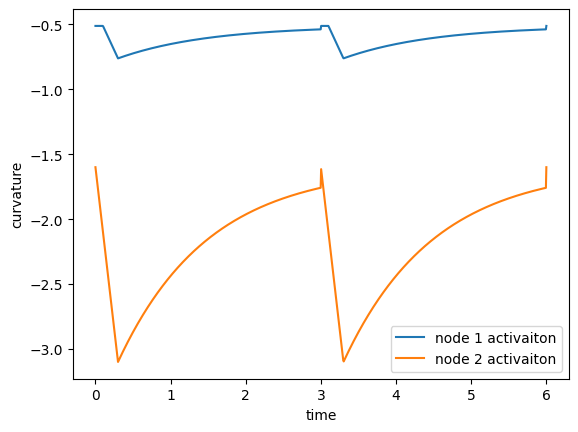

In [ ]:
def time_variant_curvature(t, natural_kappas,
                           delta_top, delta_bottom,
                           period, delay, hold_time,
                           decay_time_constant):
    """
    Calculate curvature changes that ADD to the natural bell curvature.
    Now the jellyfish goes from bell → deep bell → bell

    Parameters:
    - t: time
    - natural_kappas: the resting curvature (from initial bell shape)
    - delta_top: ADDITIONAL curvature change at center (rad)
    - delta_bottom: ADDITIONAL curvature change at edges (rad)
    - Other parameters as before
    """
    n_interior = len(natural_kappas)

    if n_interior <= 0:
        return np.array([])

    # Start with natural curvature
    kappa_total = natural_kappas.copy()

    time_contraction = t % period
    center_idx = n_interior // 2

    # Define power stroke and recovery stroke
    power_stroke_duration = period * .1
    recovery_stroke_duration = period * .9

    for i in range(n_interior):
        # Distance from center
        dist_from_center = abs(i - center_idx) / max(center_idx, 1)

        # Interpolate additional curvature change
        peak_delta = delta_top - (delta_top - delta_bottom) * dist_from_center ** 1.5

        # Apply activation delay
        node_delay = delay * dist_from_center ** 2

        if time_contraction < power_stroke_duration:
            # power stroke
            progress = (time_contraction - node_delay) / (power_stroke_duration - node_delay)
            progress = np.clip(progress, 0, 1)
            delta_kappa = peak_delta * progress #ramp to peak

        else:
          # RECOVERY STROKE
          time_in_recovery = time_contraction - power_stroke_duration
          tau = decay_time_constant * 3
          delta_kappa = peak_delta * np.exp(-time_in_recovery / tau)

        # ADD the time-varying change to the natural curvature
        kappa_total[i] = natural_kappas[i] + delta_kappa

    return kappa_total

# Jelly Parameters
delta_top = -1.5  # Maximum angle at center(rad)
delta_bottom = -.25 # Angle change at edges
period = 3 # Contraction period (seconds)
delay = .1 # Delay between center and edge
hold_time = .3 # Time to hold at peak
decay_time_constant = .4 #decay rate
natural_kappas_test = np.array([-0.51203075, -1.6, -0.51203075])
nv = 5

t_vec = np.linspace(0,6,1000)
acts = np.zeros((nv-2,len(t_vec)))
for i, t in enumerate(t_vec):
  acts[:,i] = time_variant_curvature(t, natural_kappas_test,
                           delta_top, delta_bottom,
                           period, delay, hold_time,
                           decay_time_constant)

plt.gca().set_aspect('auto')
for i in range(nv//2):
  plt.plot(t_vec,acts[i,:],label=f'node {i+1} activaiton')
plt.legend()
plt.xlabel('time')
plt.ylabel('curvature')
plt.show()

In [ ]:
def kappa_time(t, X):
    """
    Periodic function:
      - Rises 0 -> 1 in time X
      - Falls 1 -> 0 in time 10X
      - Repeats every 11X

    t : float or array-like
    X : positive float
    """
    t_arr = np.asarray(t, dtype=float)
    T = 11.0 * X                     # period
    tau = np.mod(t_arr, T)           # phase in [0, 11X)

    out = np.empty_like(t_arr)

    # Rise: 0 -> 1 over [0, X)
    rise_mask = tau < X
    out[rise_mask] = np.sin(0.5 * np.pi * tau[rise_mask] / X)

    # Fall: 1 -> 0 over [X, 11X)
    fall_mask = ~rise_mask
    out[fall_mask] = np.cos((np.pi / (20.0 * X)) * (tau[fall_mask] - X))

    # Return scalar if input was scalar
    if np.isscalar(t):
        return float(out)
    return out

def kappa_plot():
  # Plot
  X = 1.0
  t = np.linspace(0, 33, 1000)  # three periods
  y = kappa_time(t, X)

  plt.figure()
  plt.plot(t, y)
  plt.xlabel("t")
  plt.ylabel("kappa(t)")
  plt.title("Periodic kappa(t)")
  plt.show()

# Main

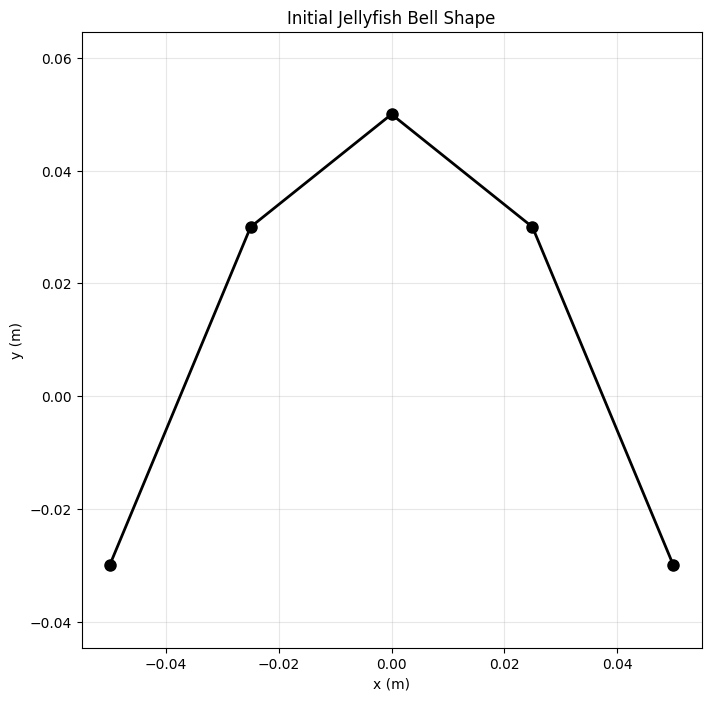

In [ ]:
# Inputs
nv = 5 # number of nodes
ne = nv - 1
ndof = 2*nv

# Jelly Parameters
delta_top = -1.5  # Maximum angle at center(rad)
delta_bottom = -.25 # Angle change at edges
period = 3 # Contraction period (seconds)
delay = .1 # Delay between center and edge
hold_time = .3 # Time to hold at peak
decay_time_constant = .4 #decay rate

# radius of the wire
r0 = .02
# Legnth of total jellyfish
L = 1
#Density of a jellyfish (kg/m^3)
rho = 1050
# Density of salt water
rho_w = 1025

Ct = 0.15
Cp = Ct*2
C_D = 0.42

# Parabola Parameters
y_center = 0.05 # y-coordinate of the top
width = .1 # Width of the bell
height = .08 # height of the bell at center

# Create our nodes matrix
nodes = np.zeros((nv, 2))

for c in range(nv):

  x = -width/2 + (c / (nv - 1)) * width

  factor = height/(width/2) ** 2

  y = -x**2 * factor + y_center

  nodes[c, 0] = x
  nodes[c, 1] = y

plt.figure(figsize=(8, 8))
plt.plot(nodes[:, 0], nodes[:, 1], 'ko-', markersize=8, linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Initial Jellyfish Bell Shape')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Mass vector and matrix
m_node = np.pi * r0**2 * L * rho / (nv - 1) # Mass per node
m = np.full(2 * nv, m_node) # Mass vector
mMat = np.diag(m)

# External forces
W = np.zeros( 2 * nv)

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
  q0[2*c] = nodes[c, 0] # x coordinate
  q0[2*c+1] = nodes[c, 1] # y coordinate # Corrected index here

u0 = np.zeros(2 * nv) # old velocity
#print(q0)

natural_kappas = compute_natural_curvature(q0)
#print('\nNatural curvatures at each interior node:')
#print(natural_kappas)

**Time stepping loop**

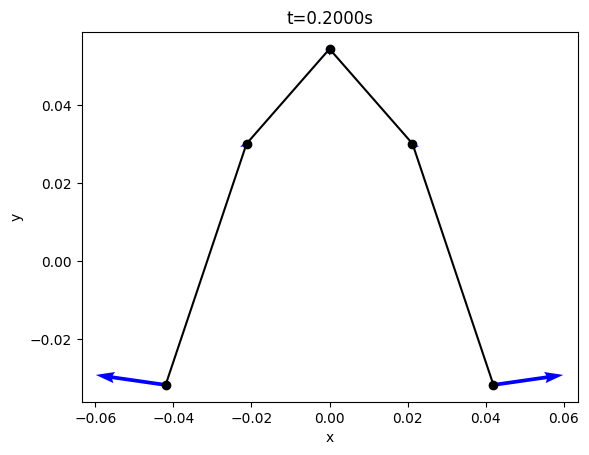

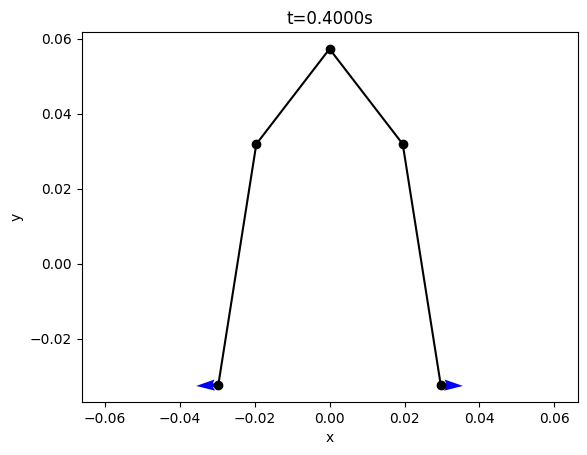

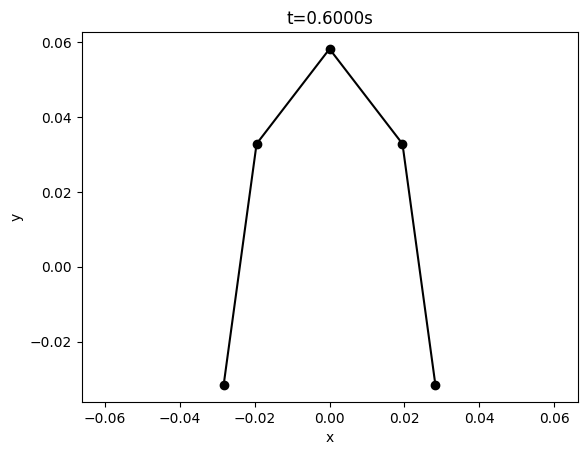

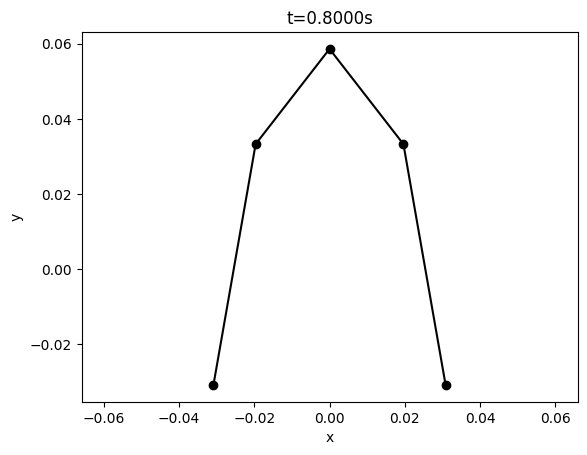

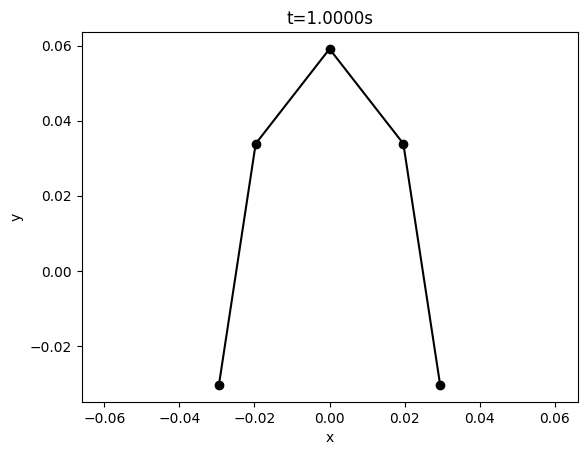

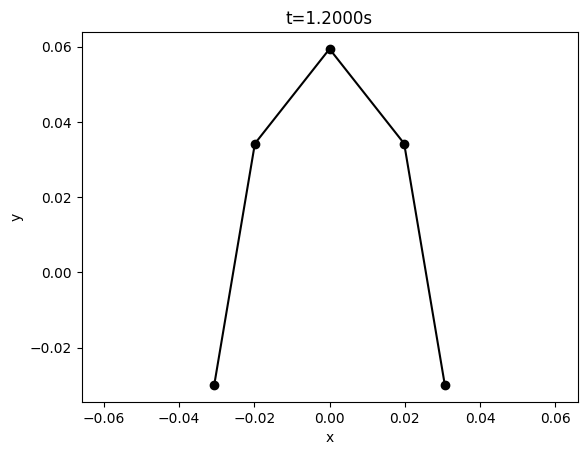

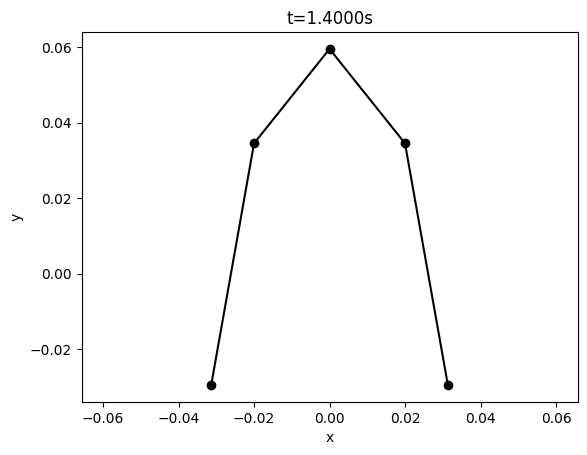

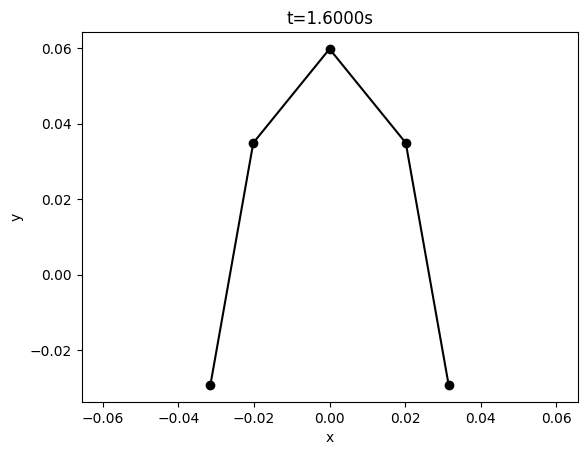

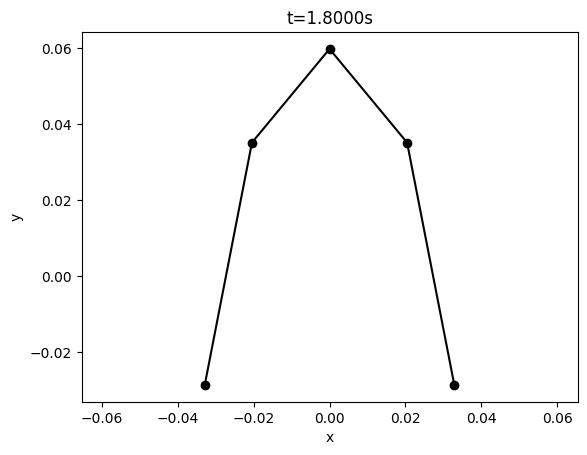

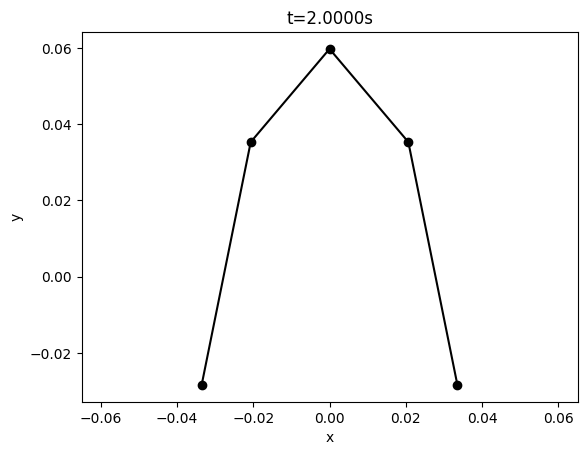

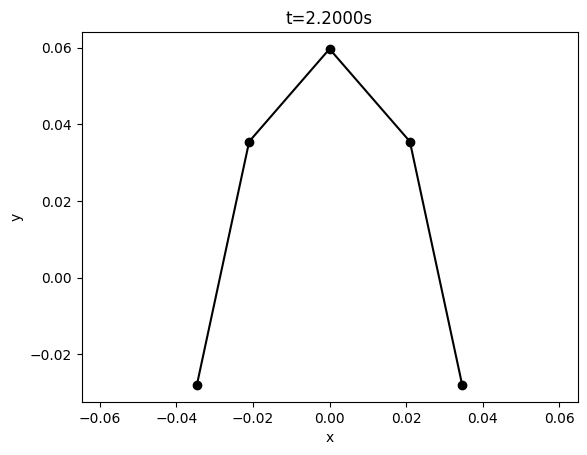

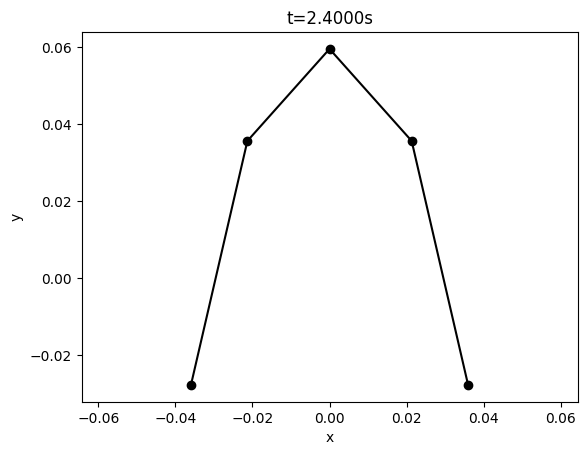

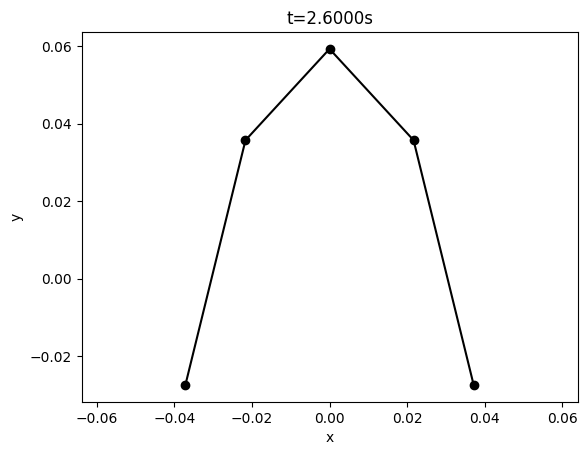

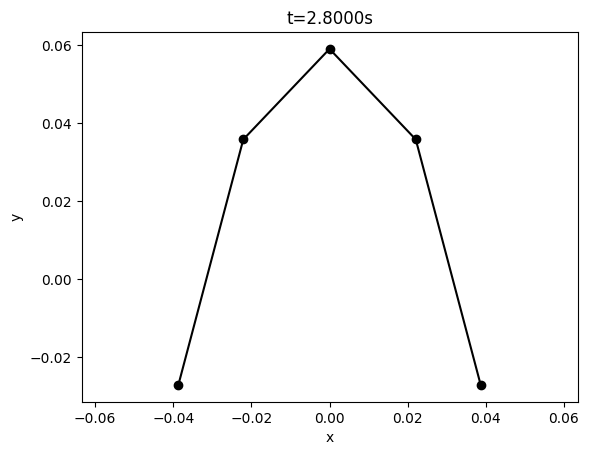

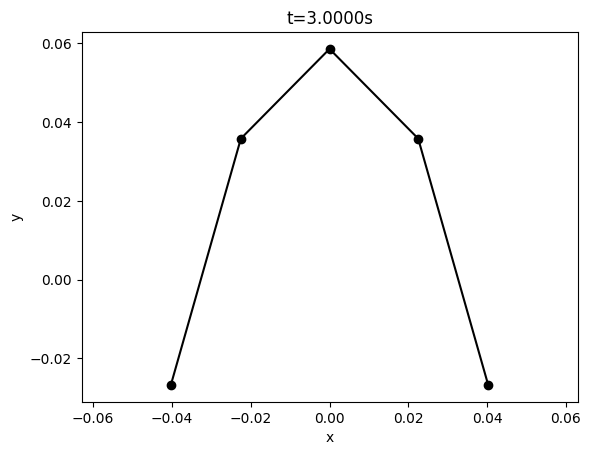

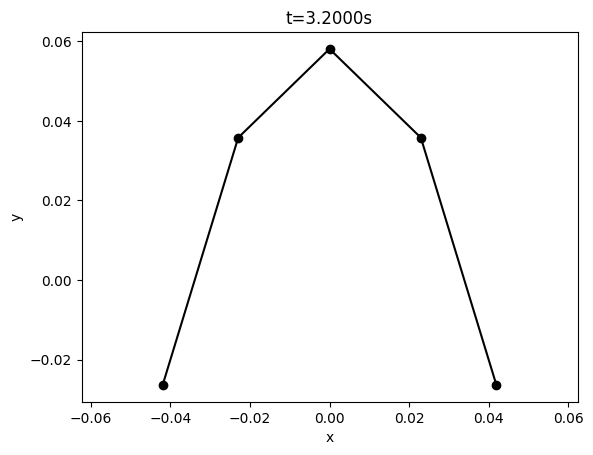

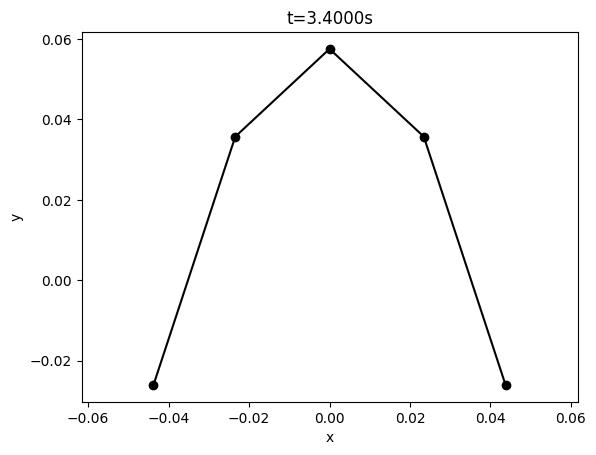

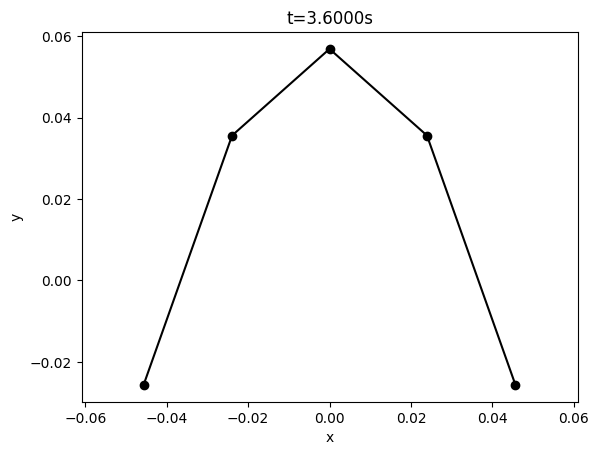

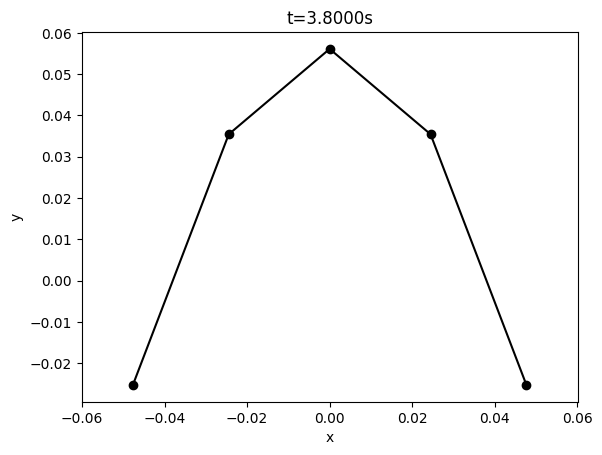

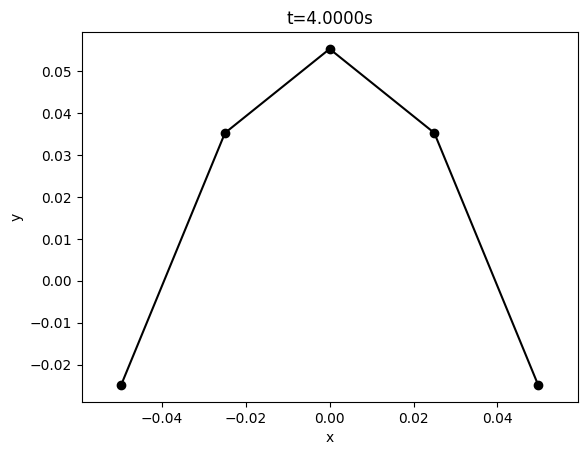

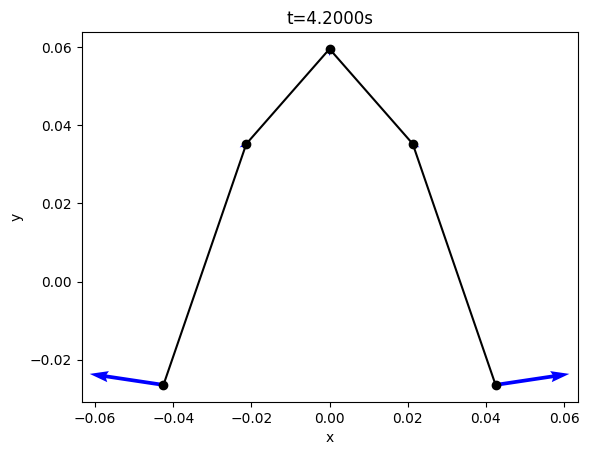

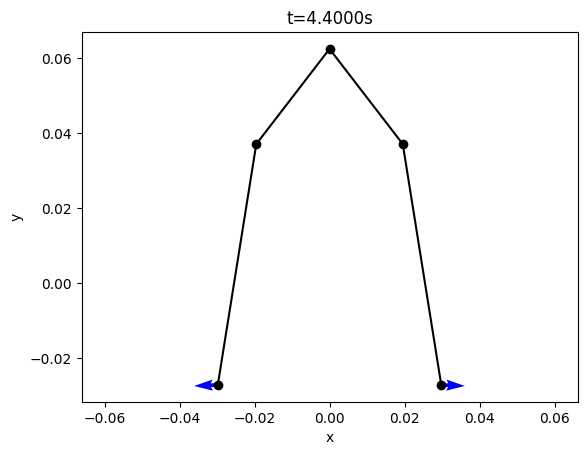

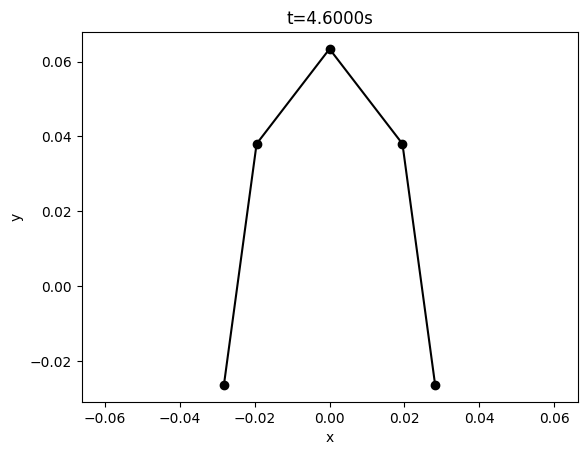

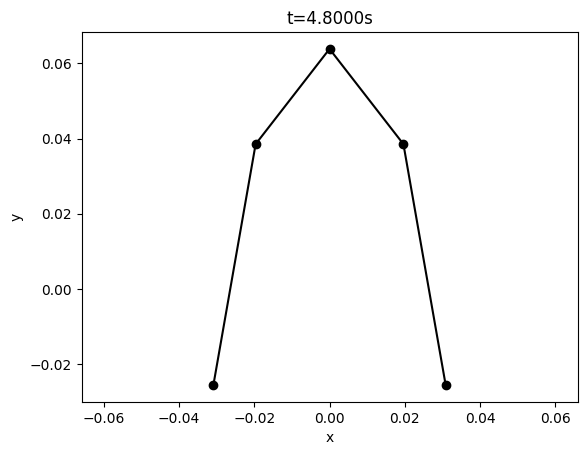

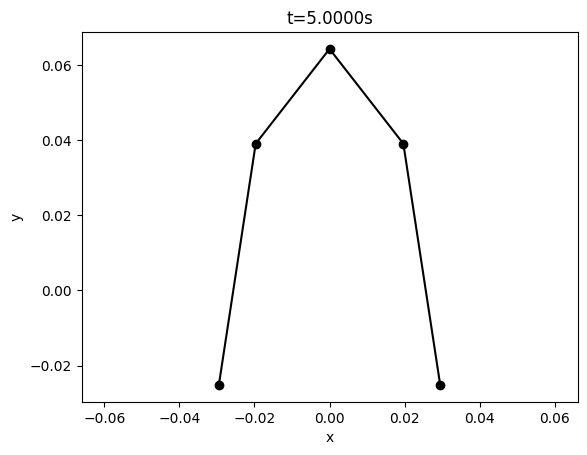

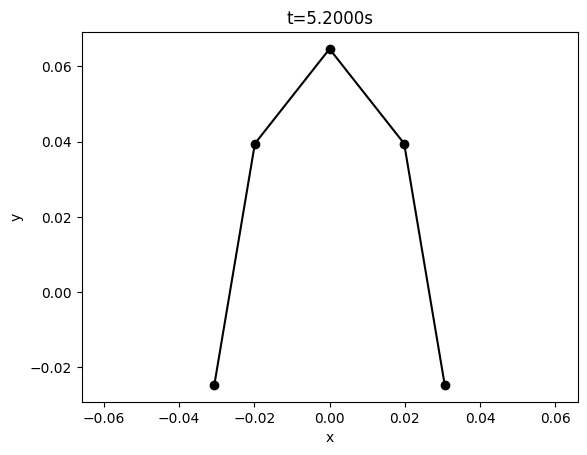

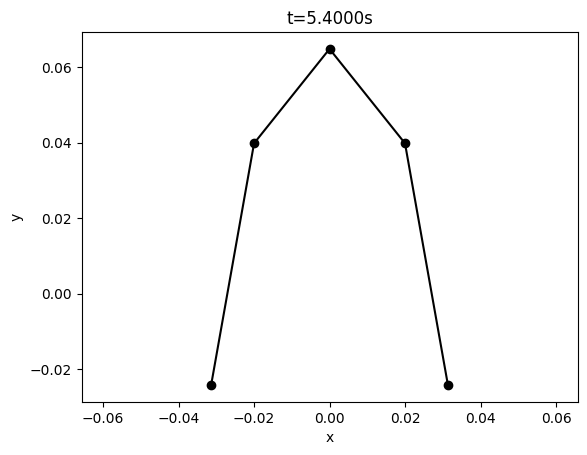

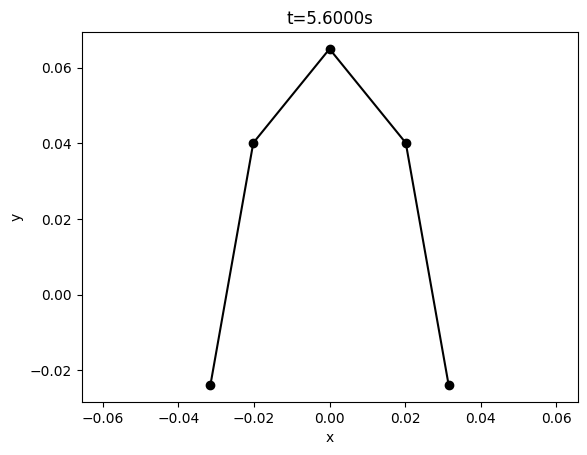

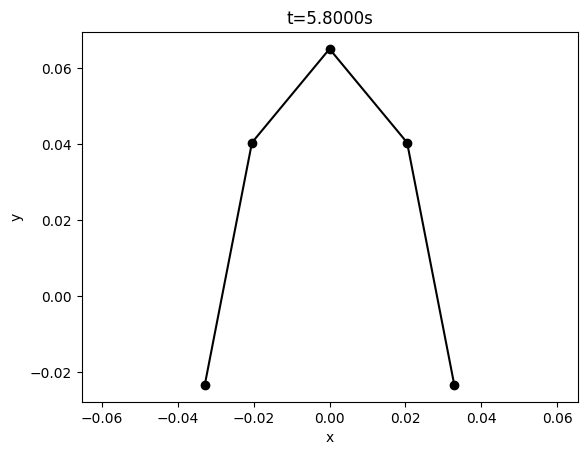

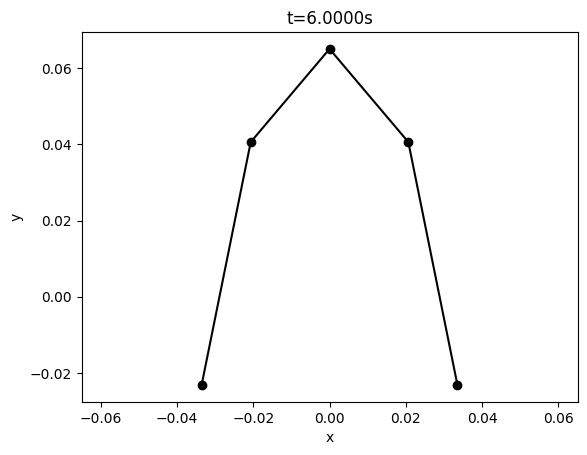

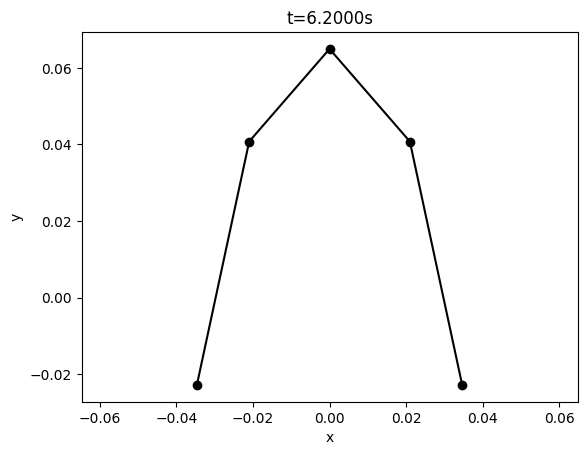

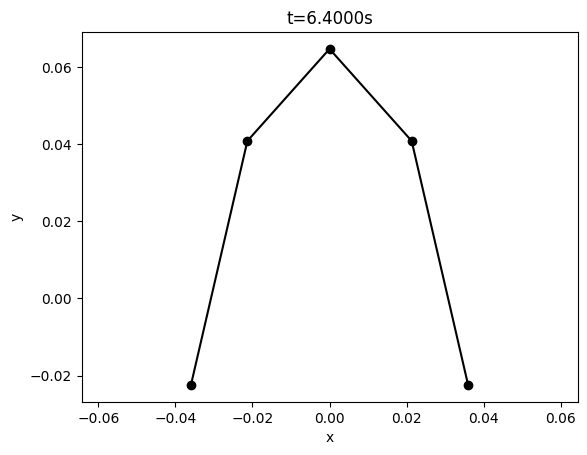

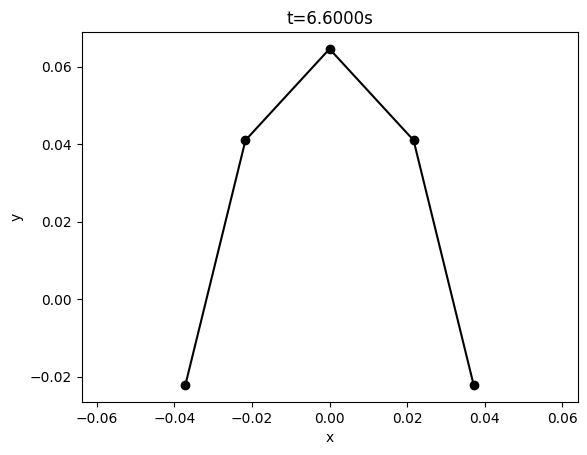

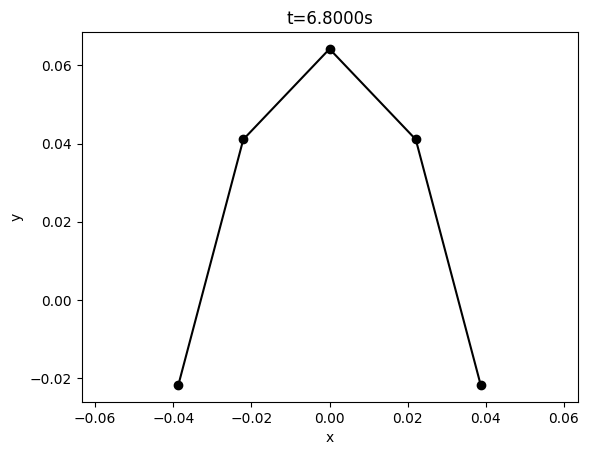

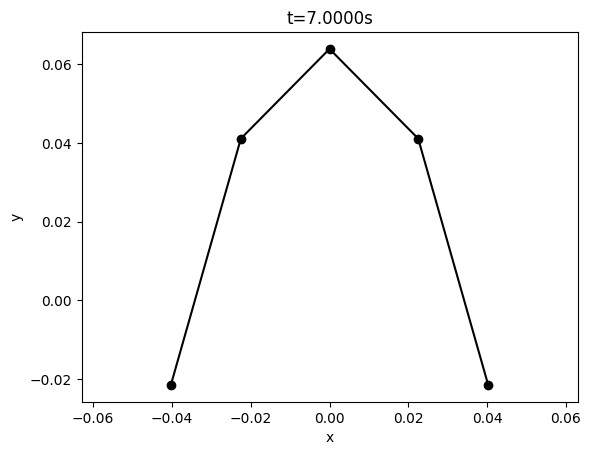

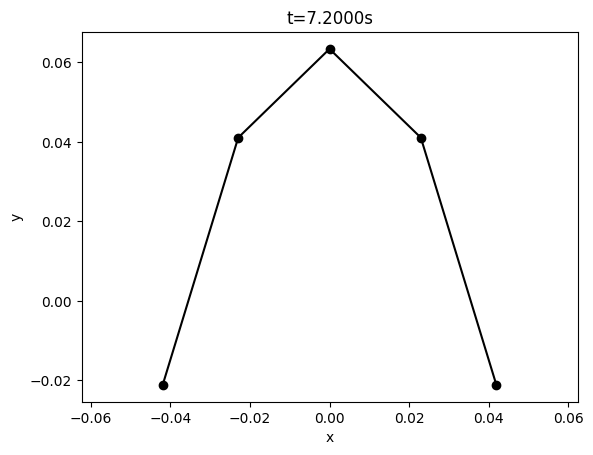

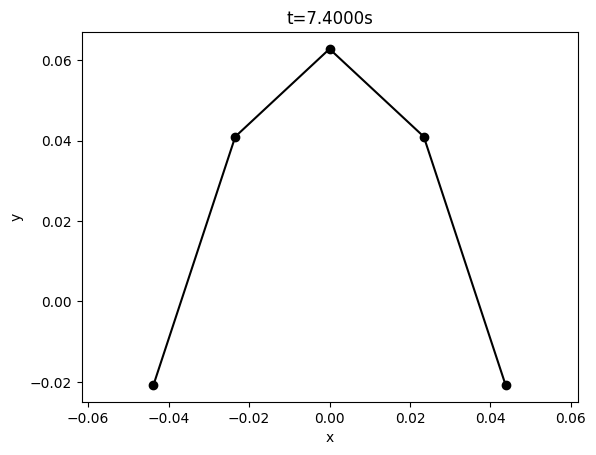

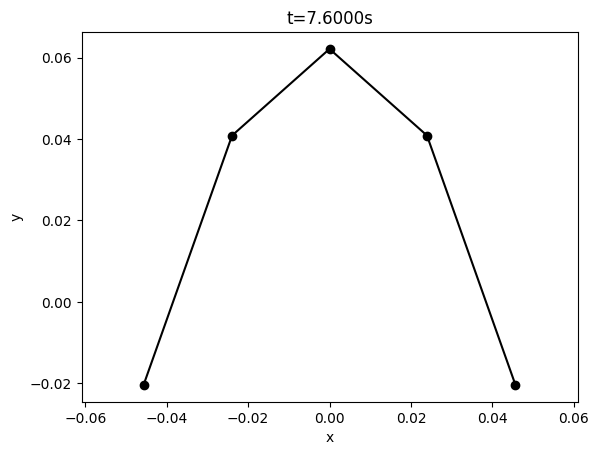

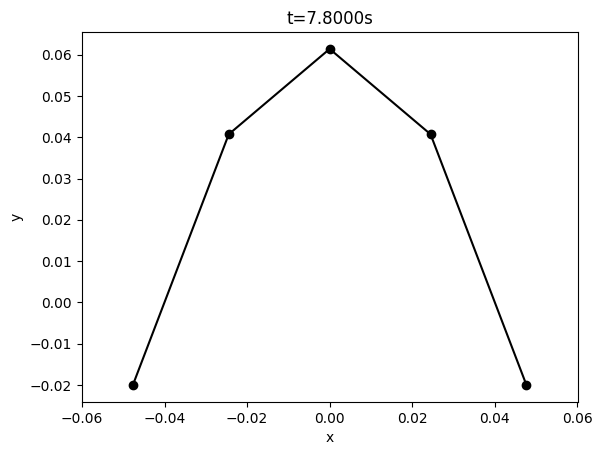

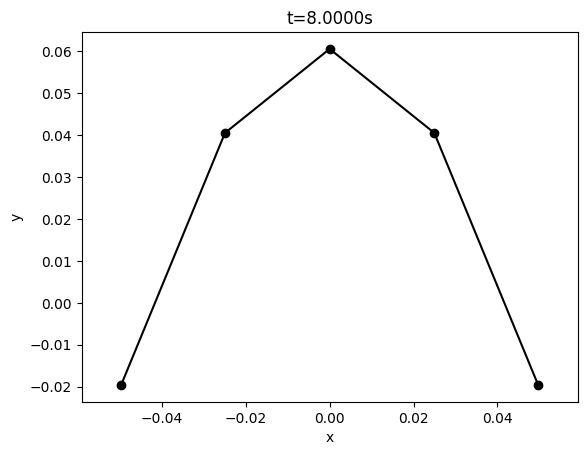

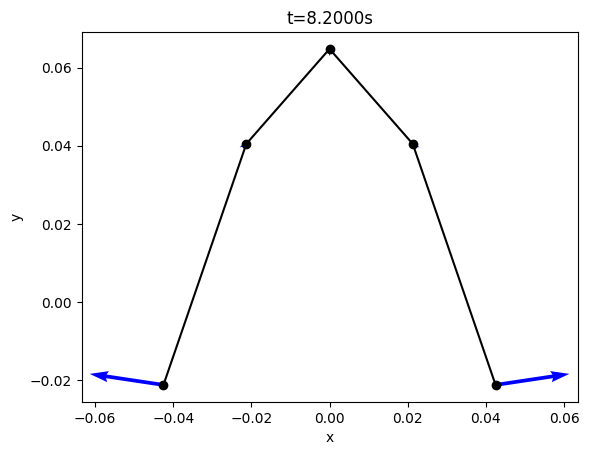

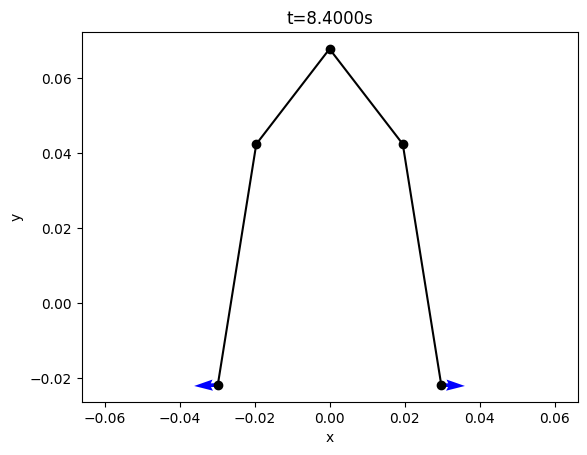

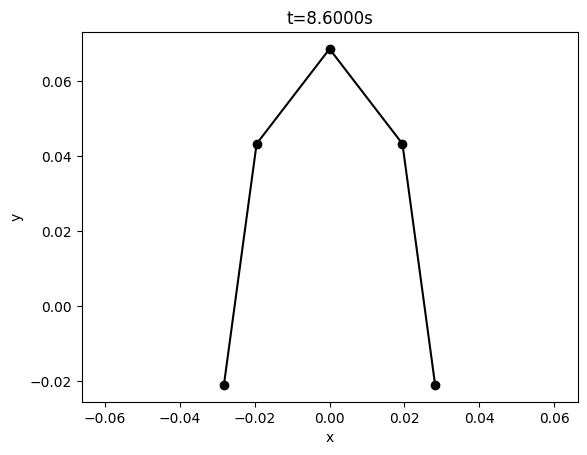

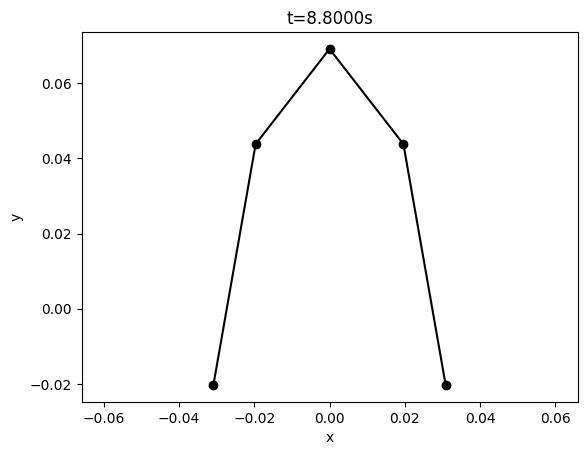

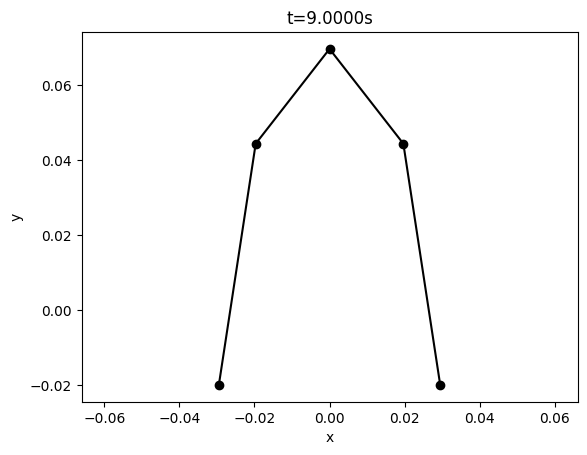

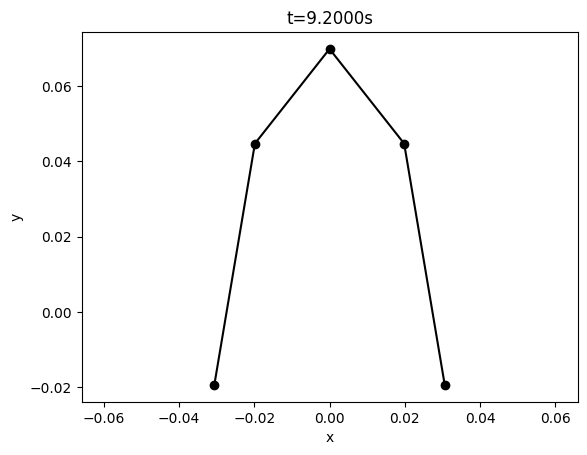

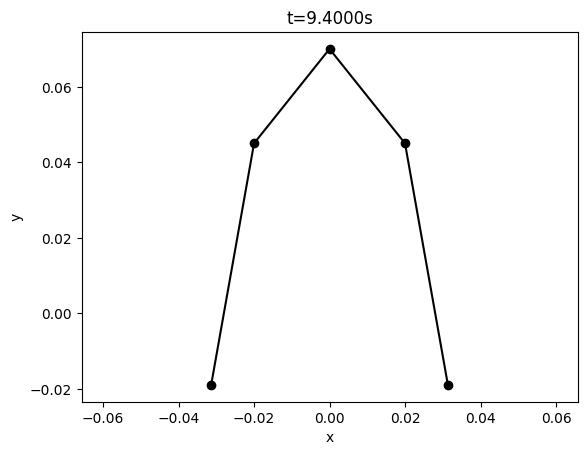

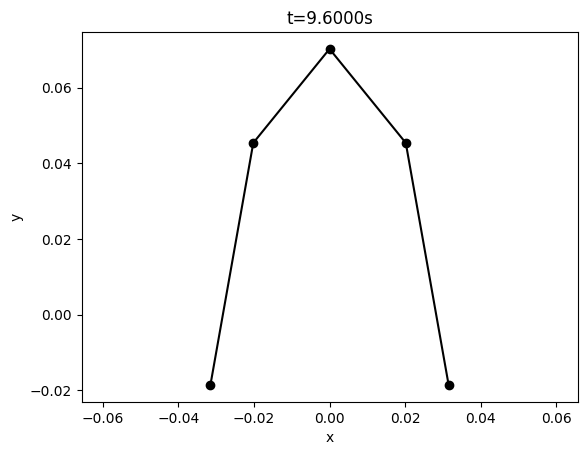

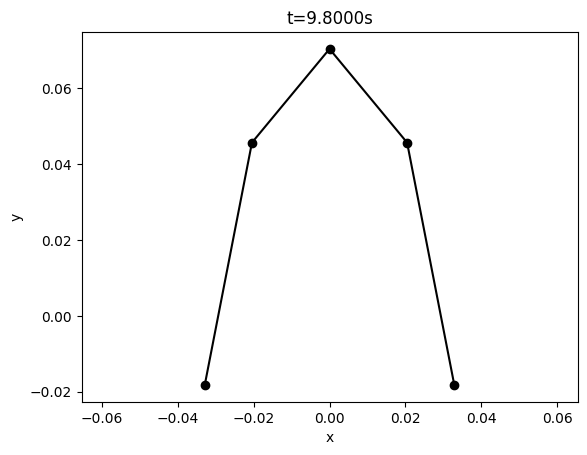

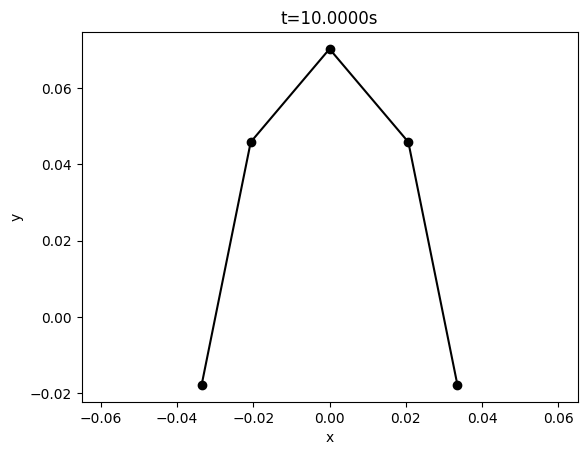

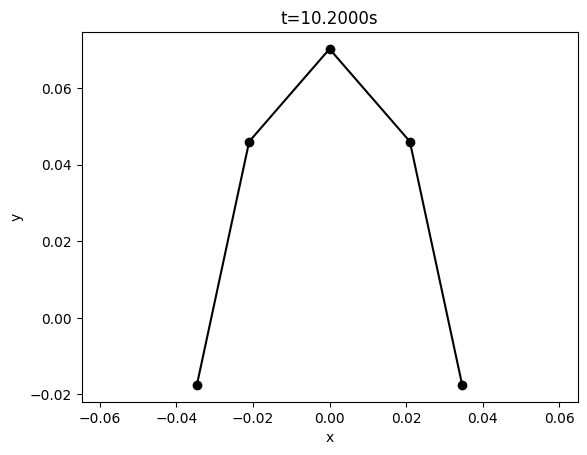

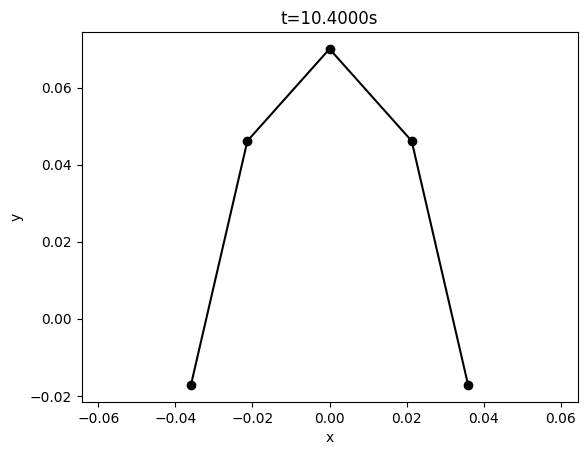

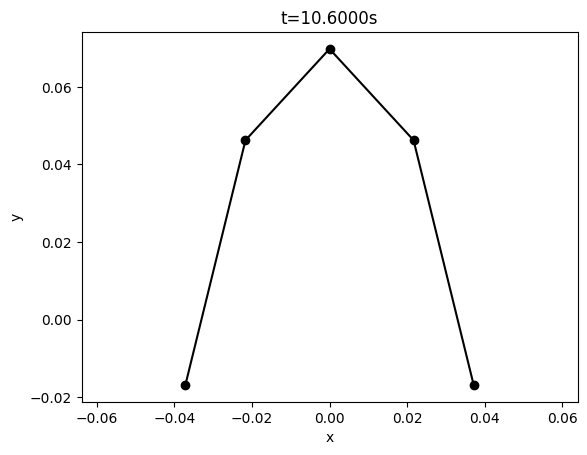

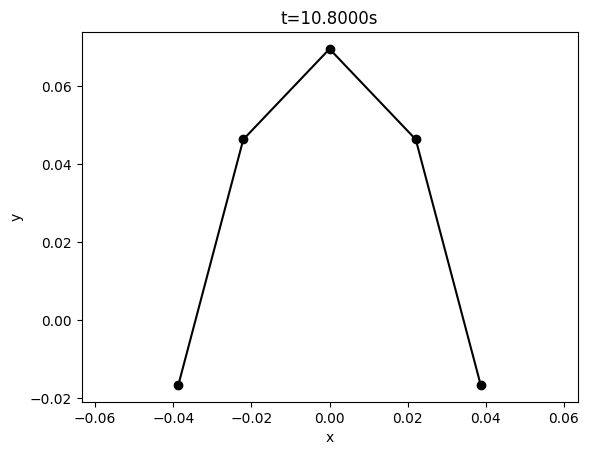

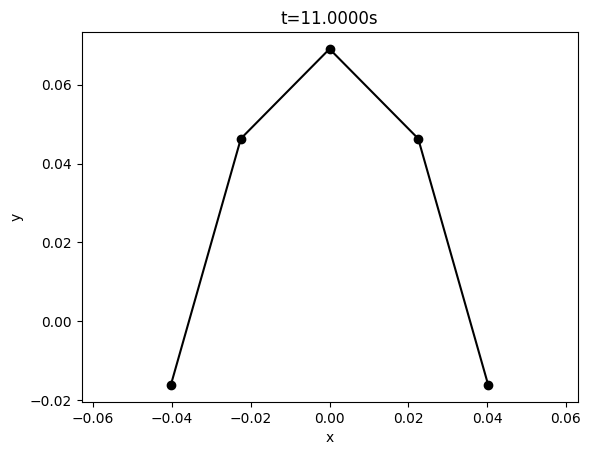

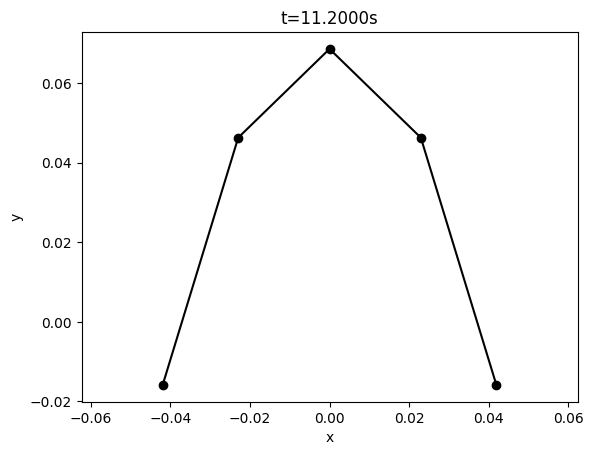

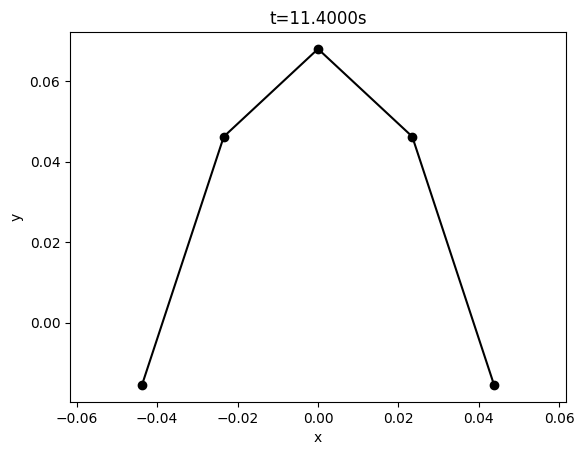

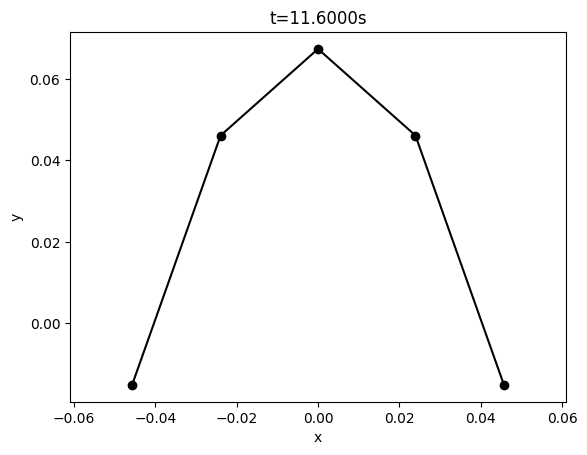

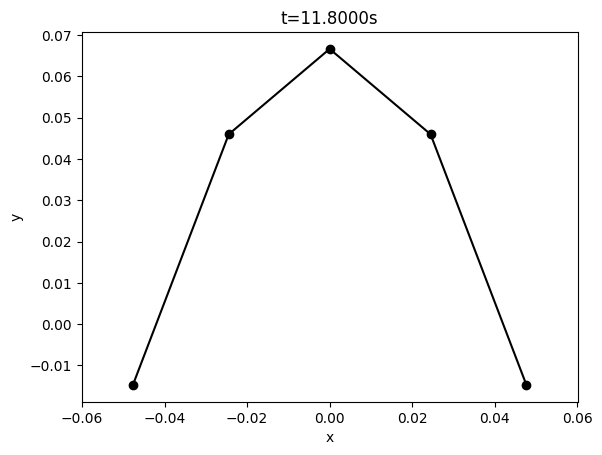

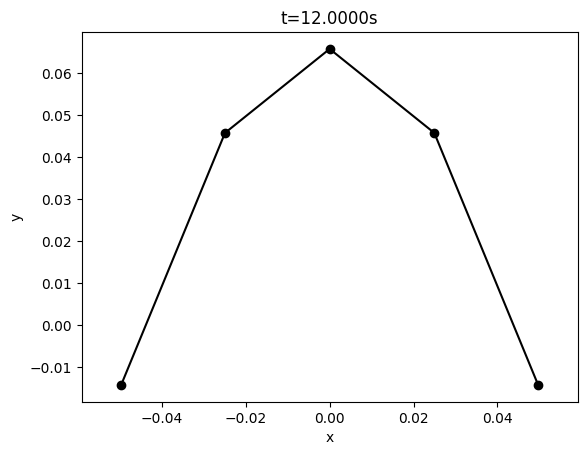

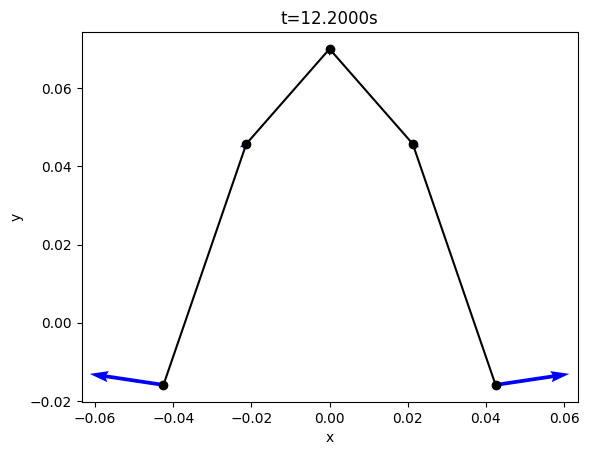

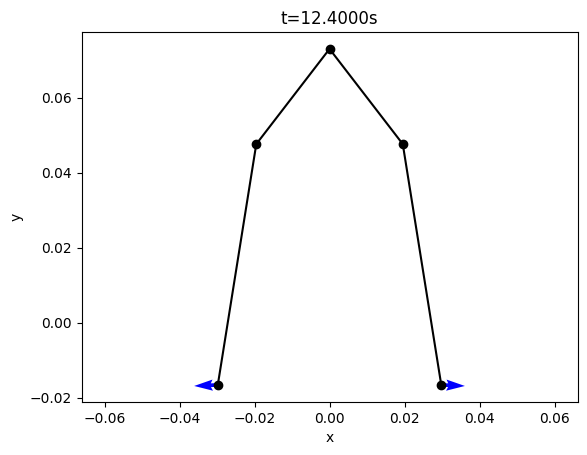

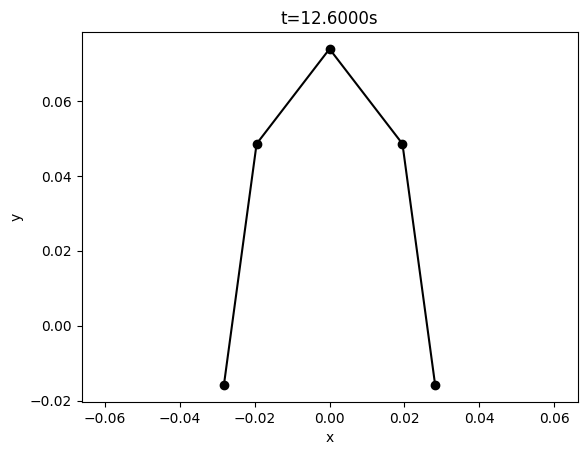

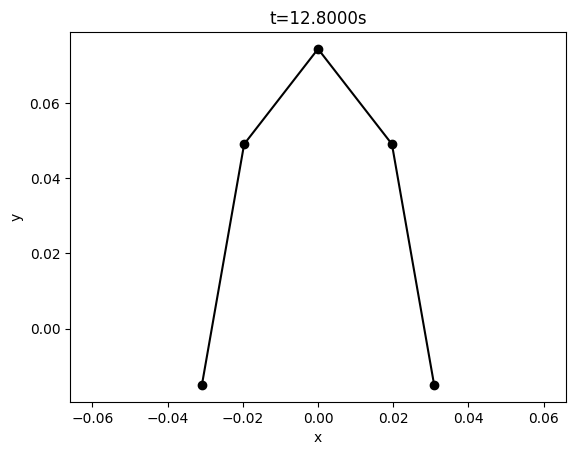

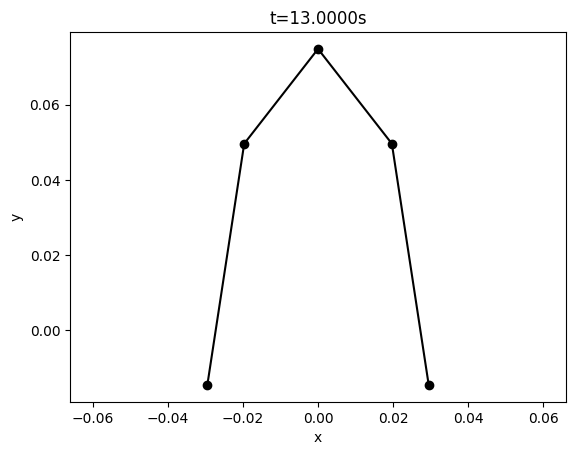

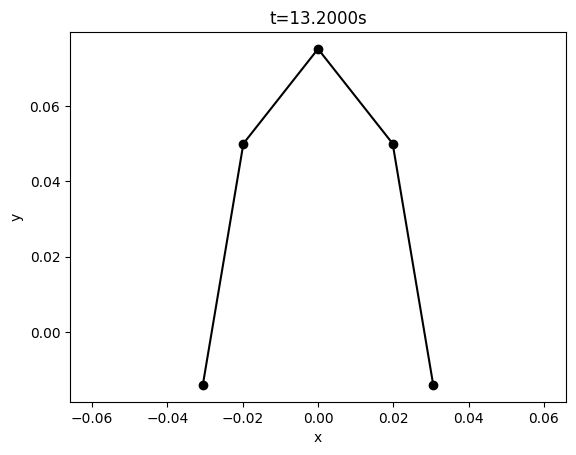

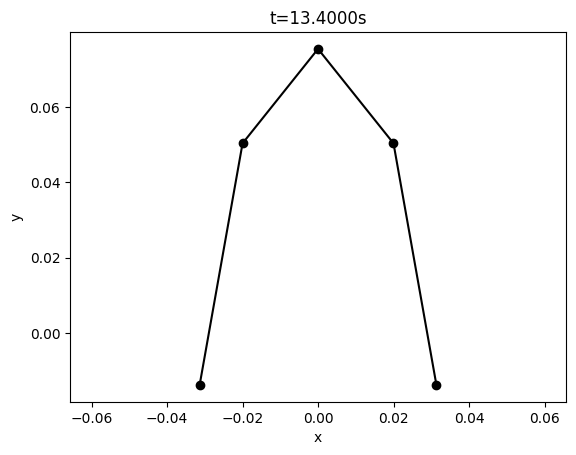

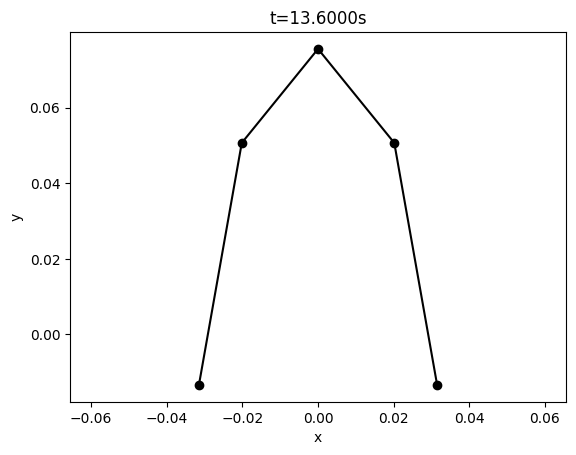

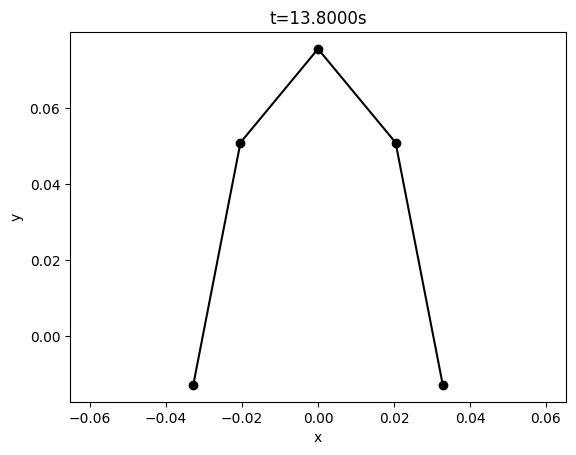

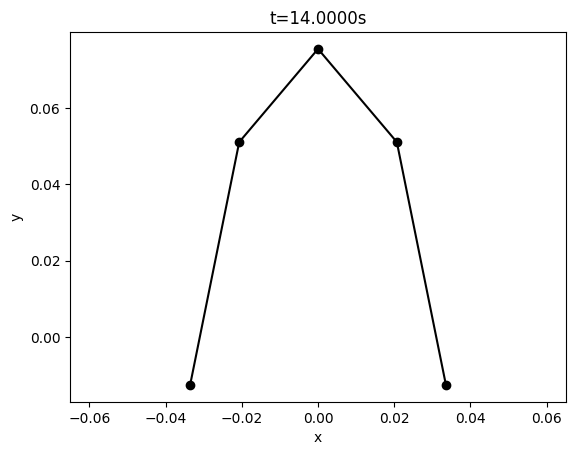

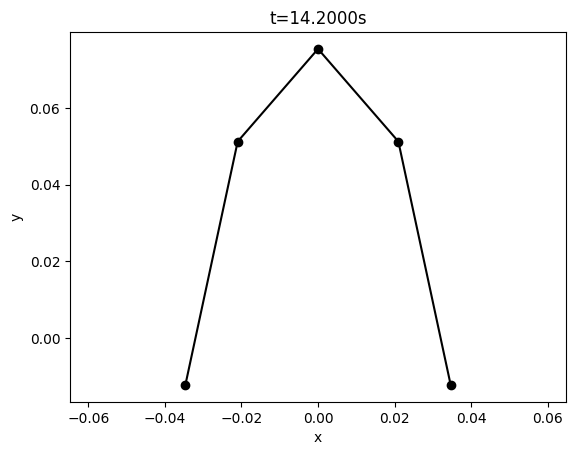

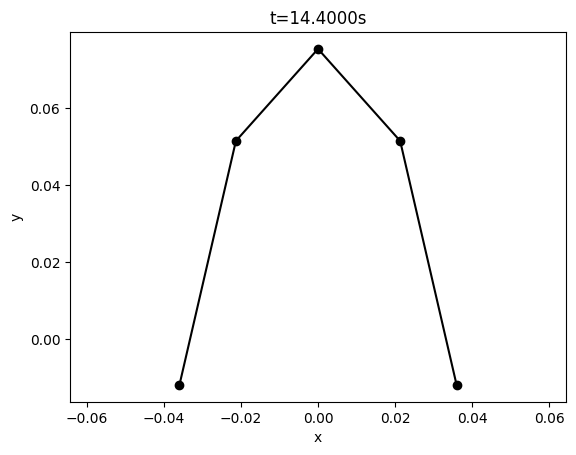

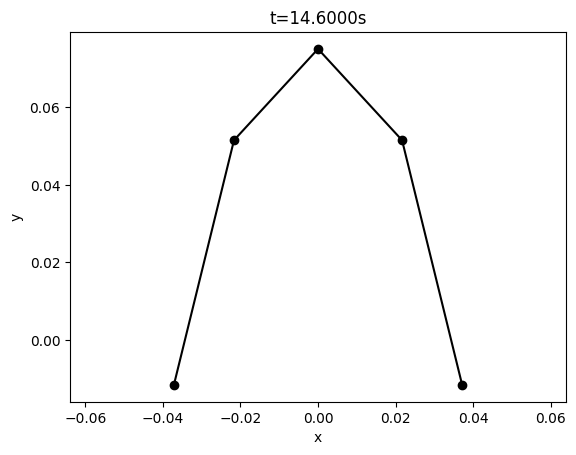

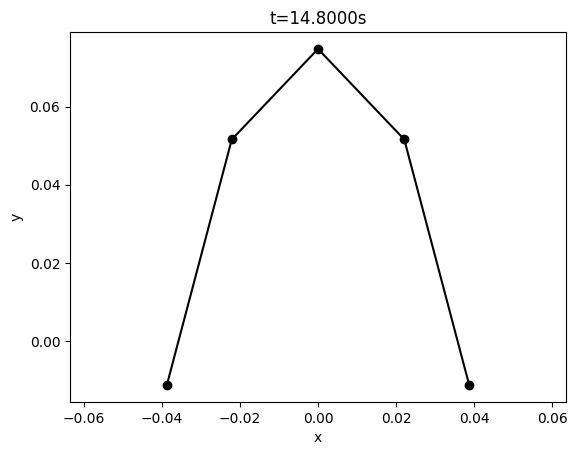

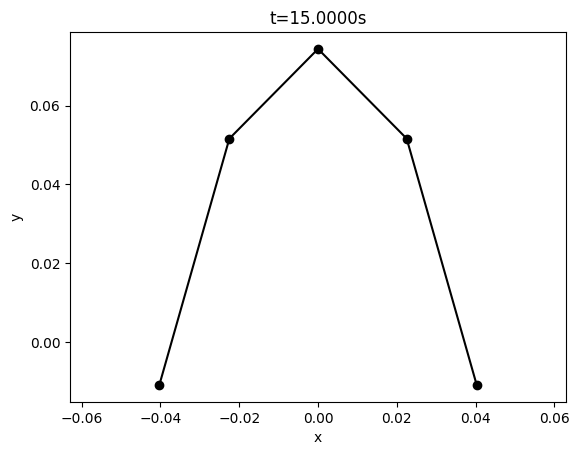

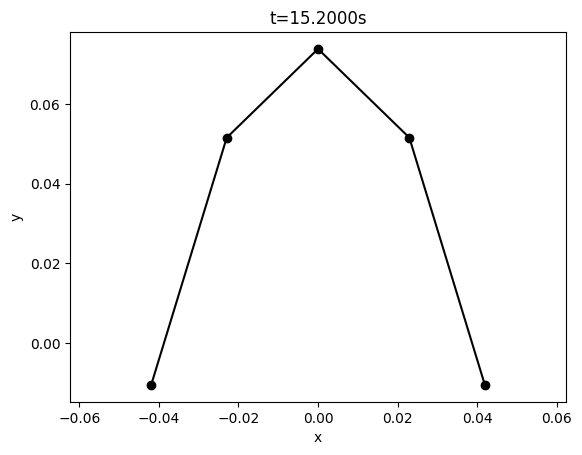

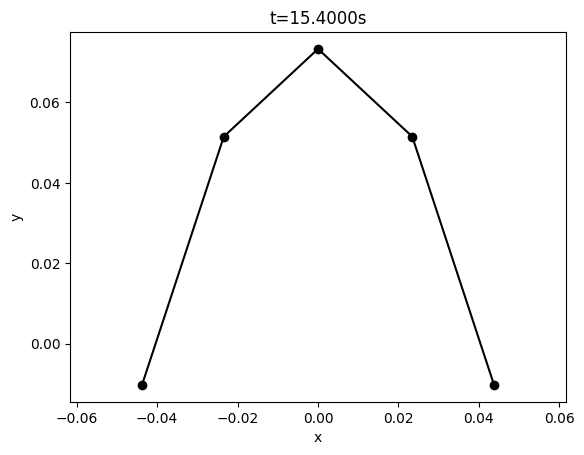

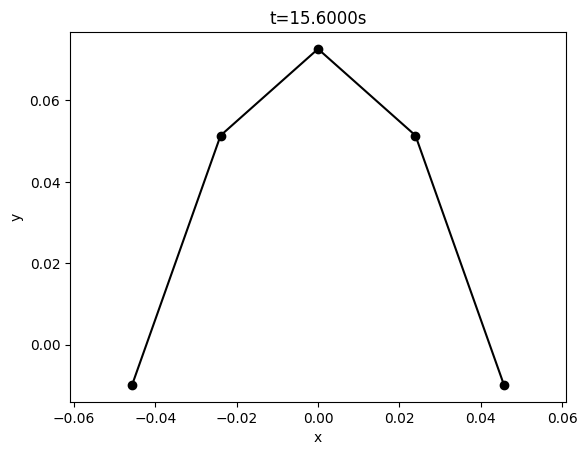

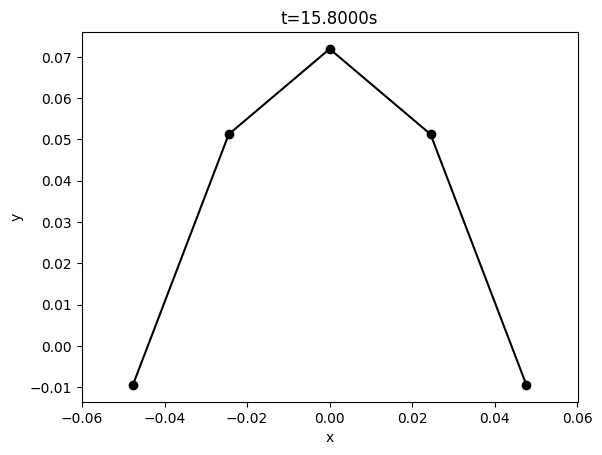

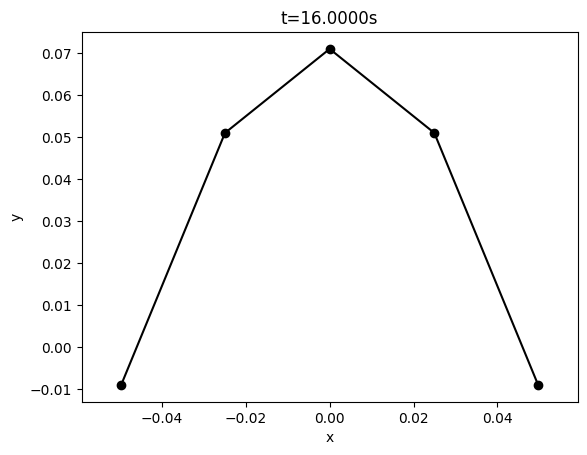

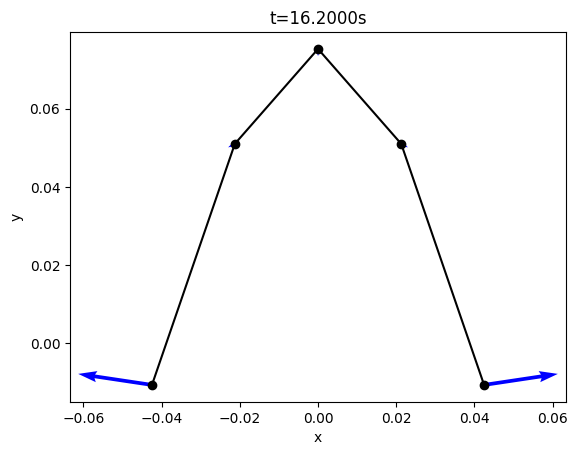

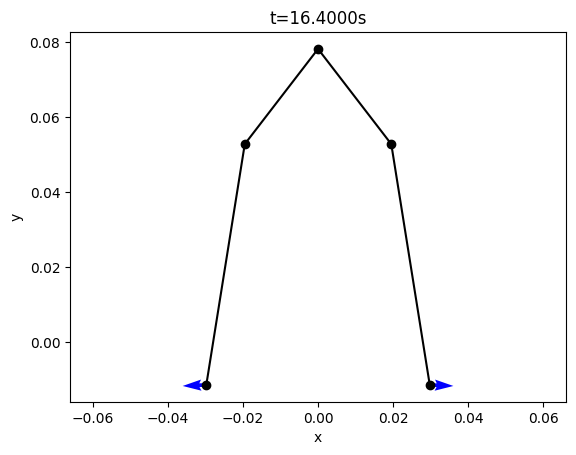

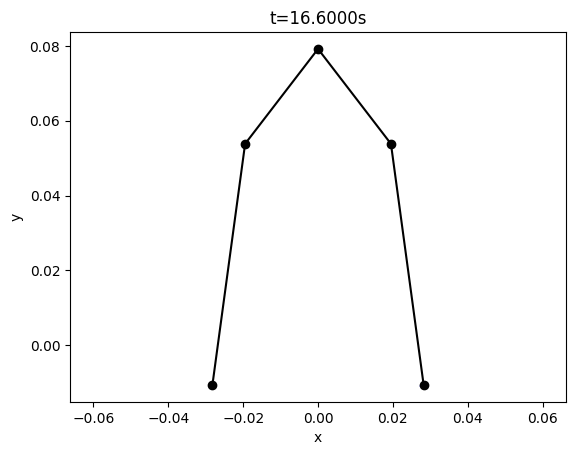

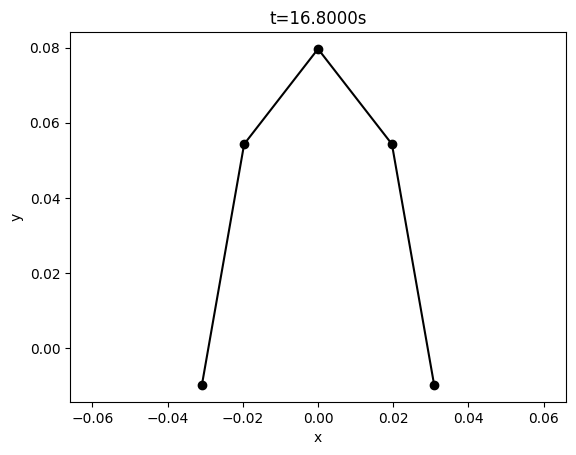

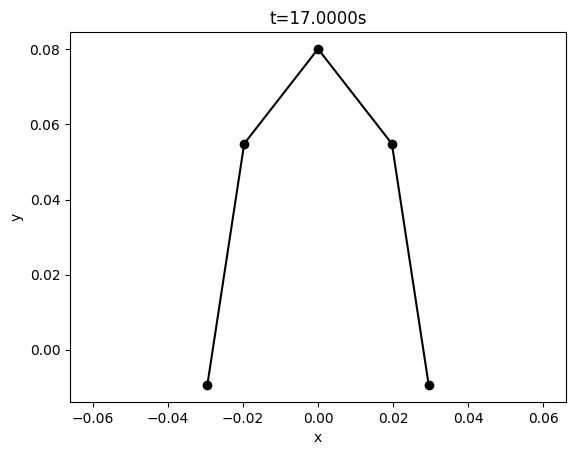

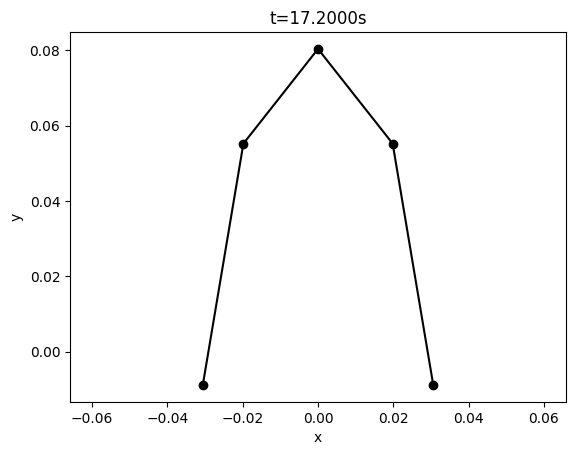

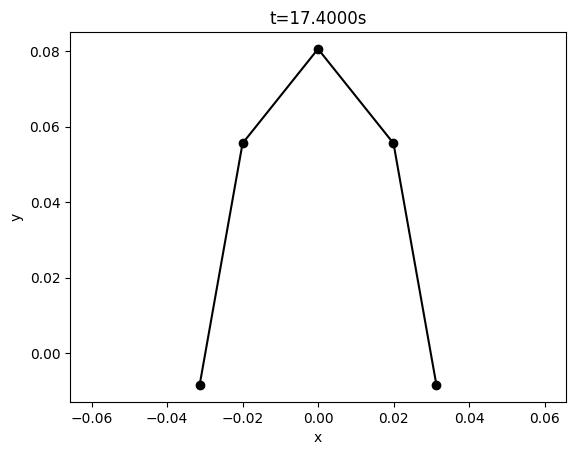

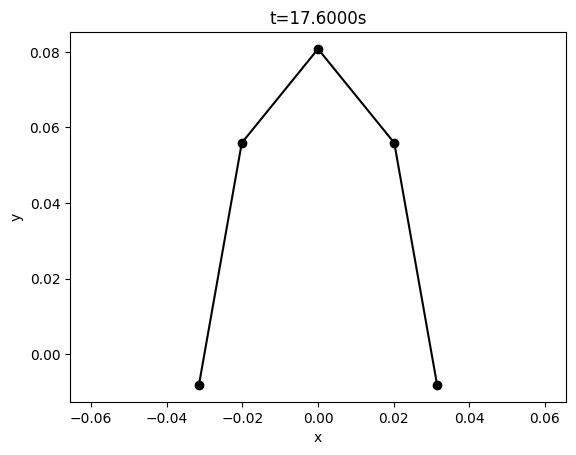

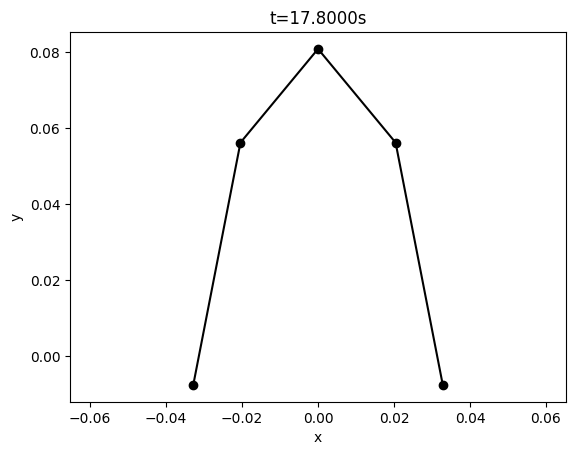

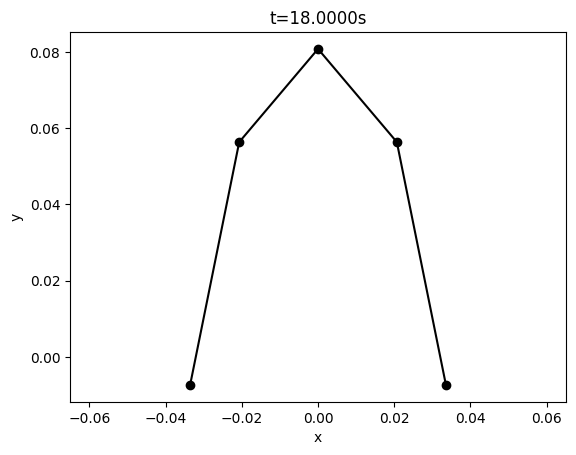

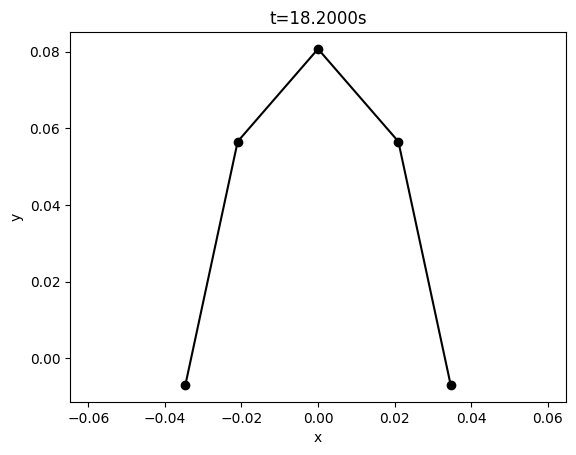

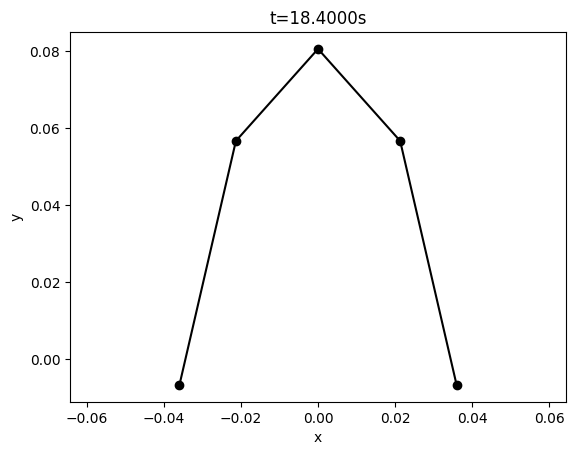

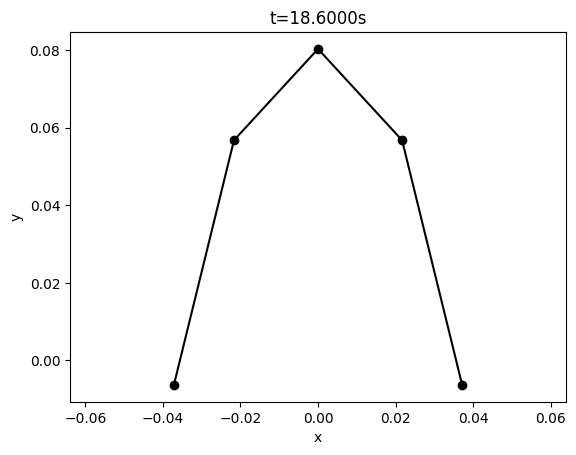

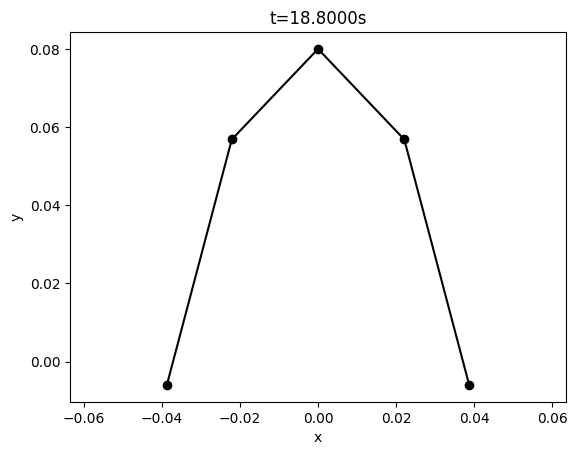

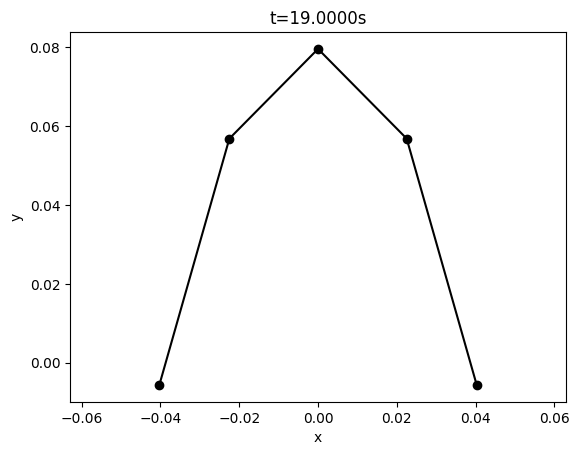

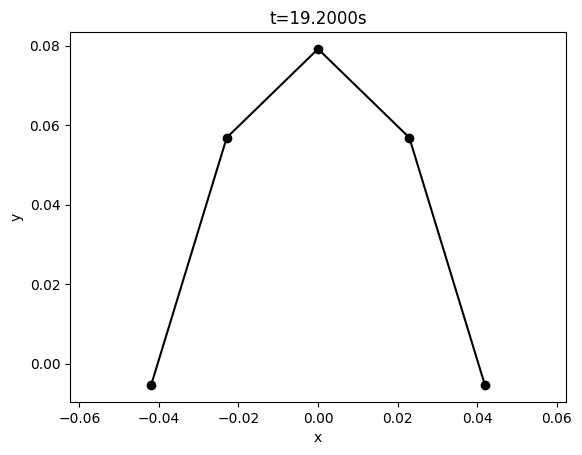

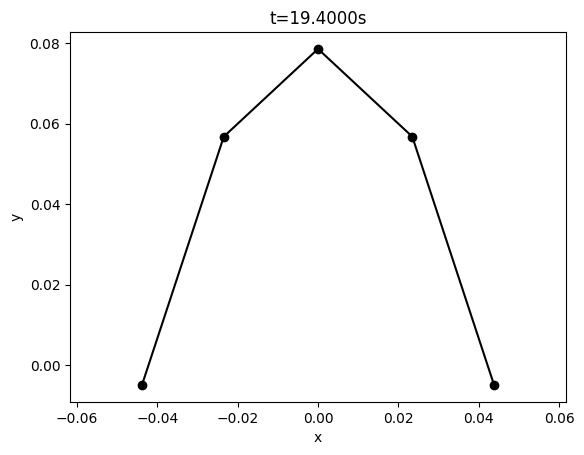

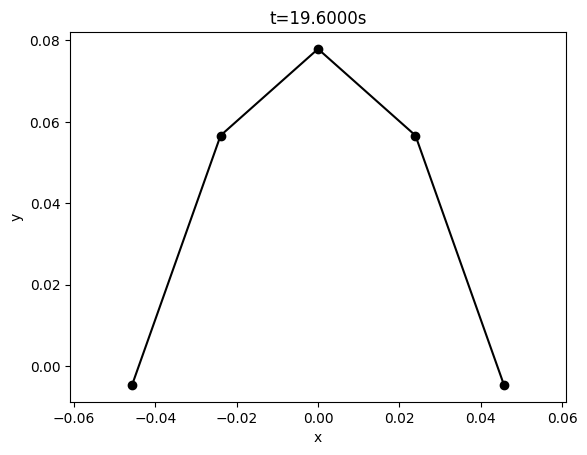

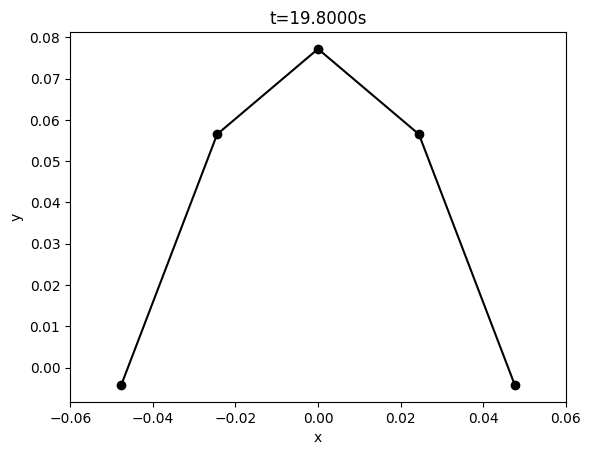

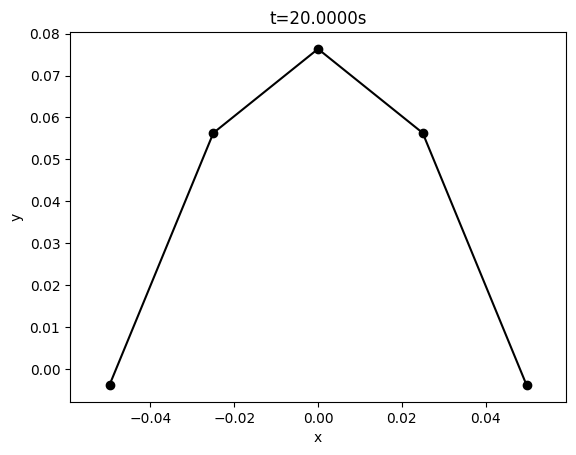

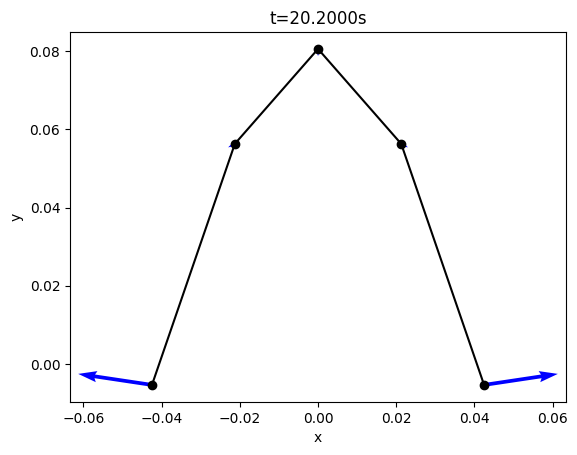

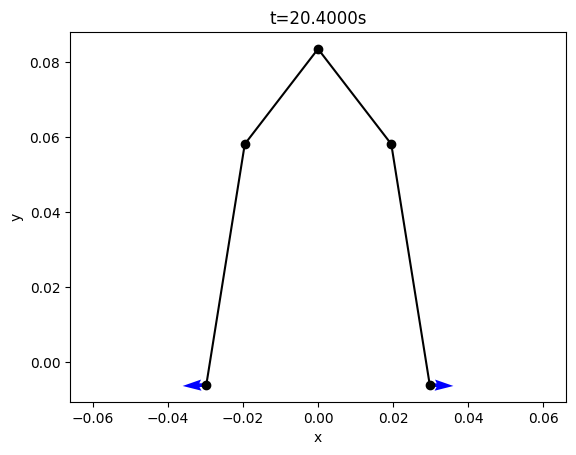

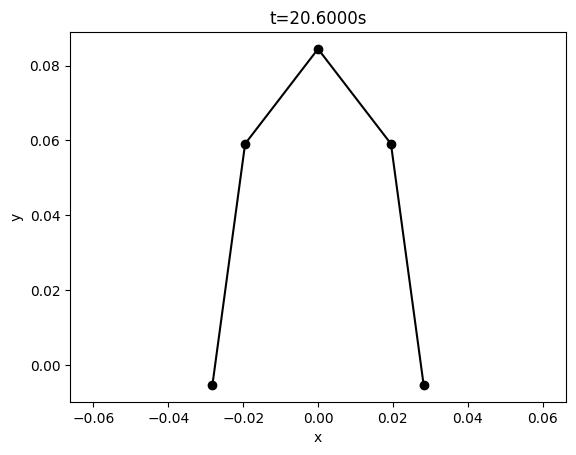

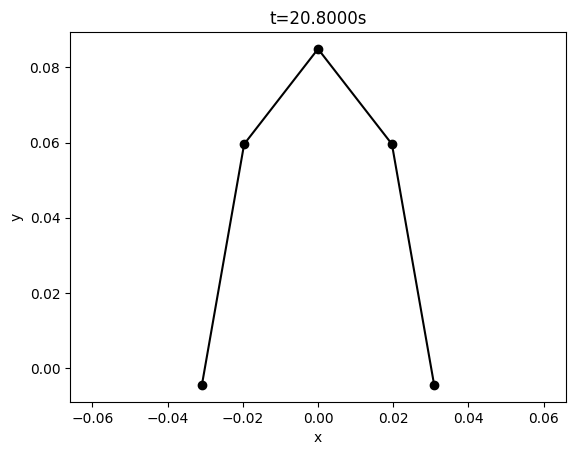

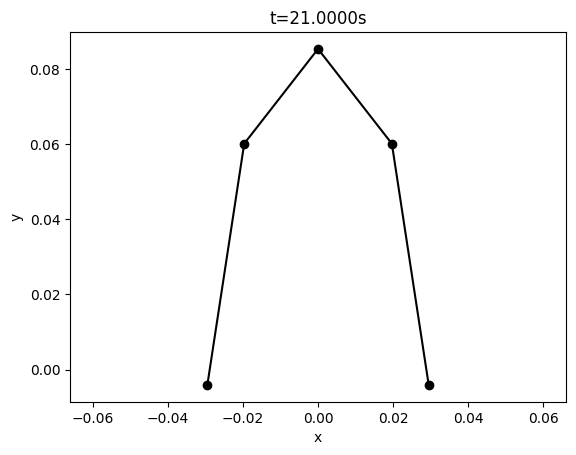

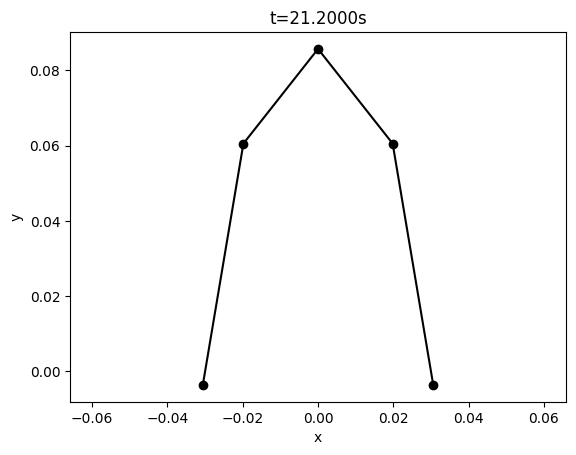

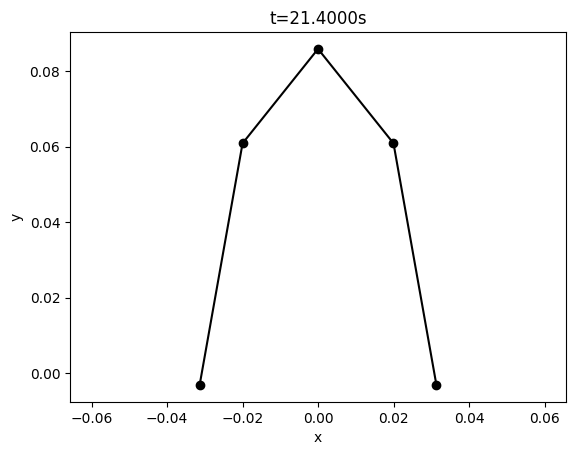

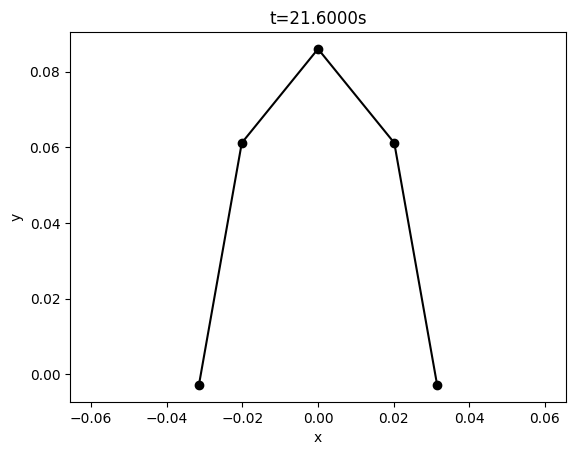

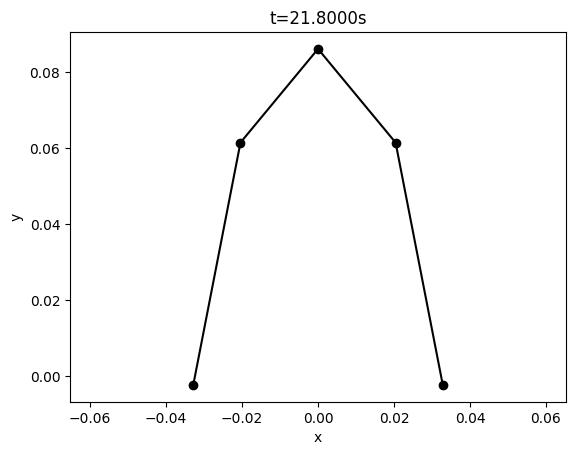

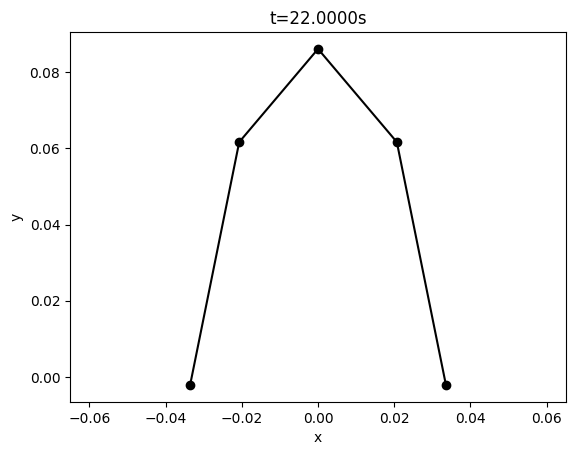

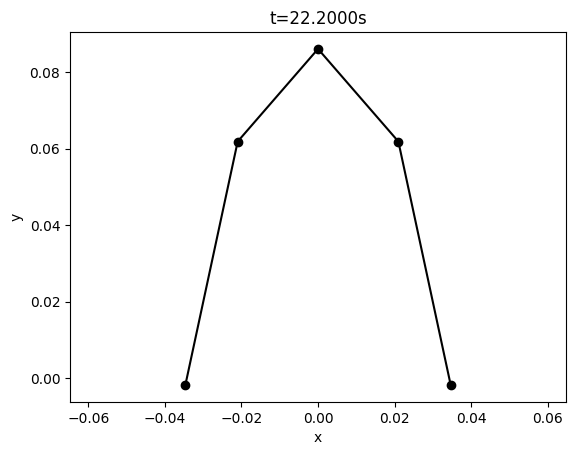

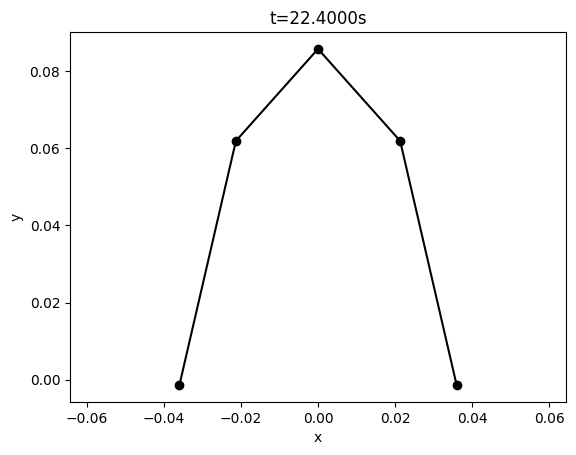

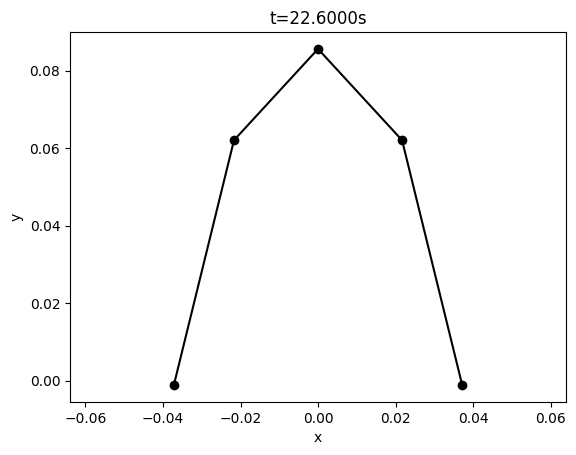

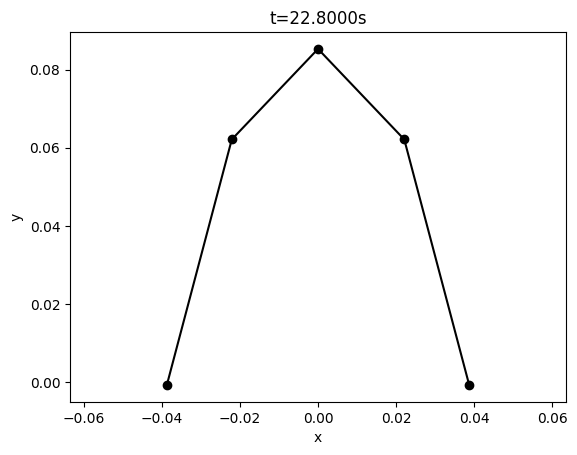

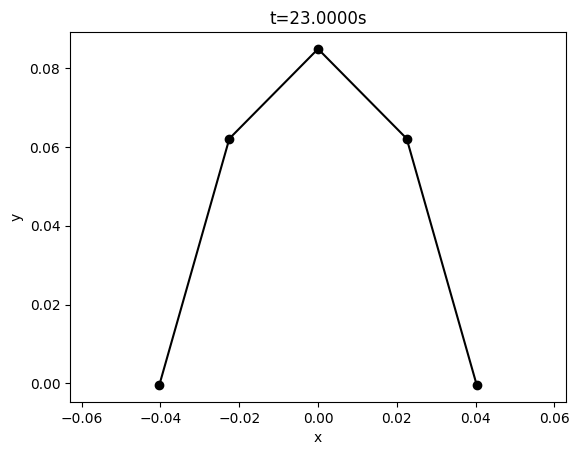

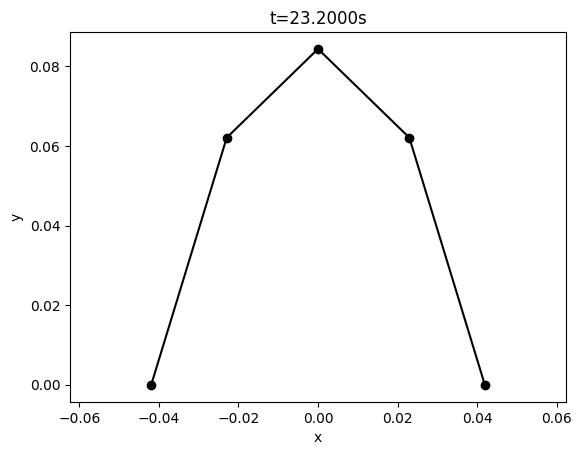

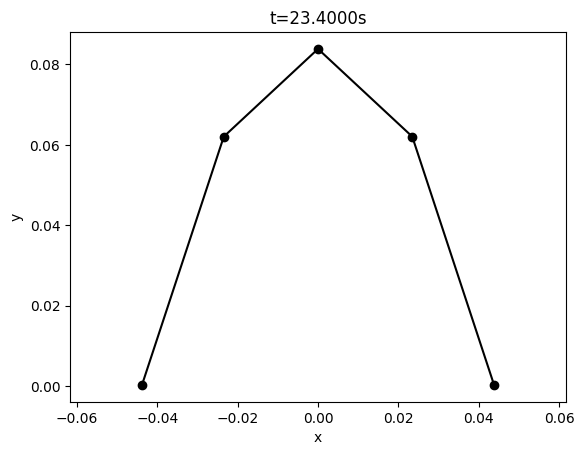

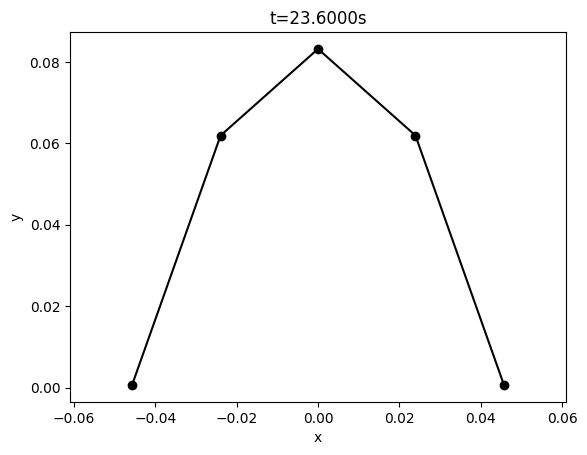

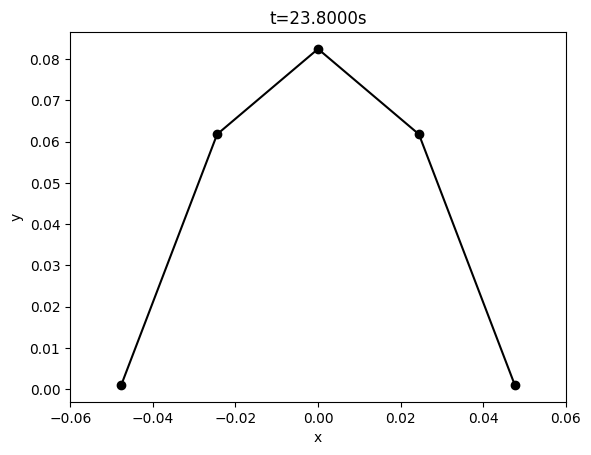

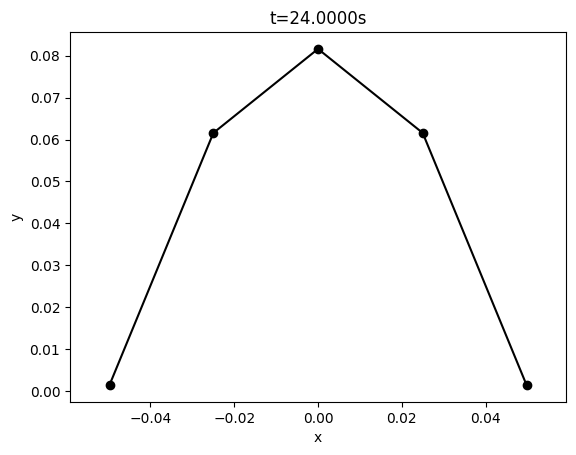

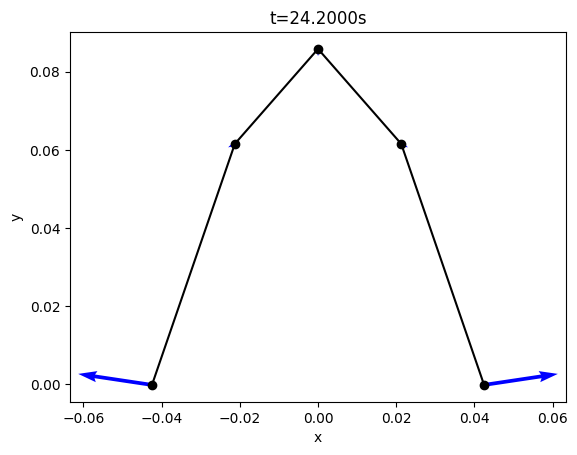

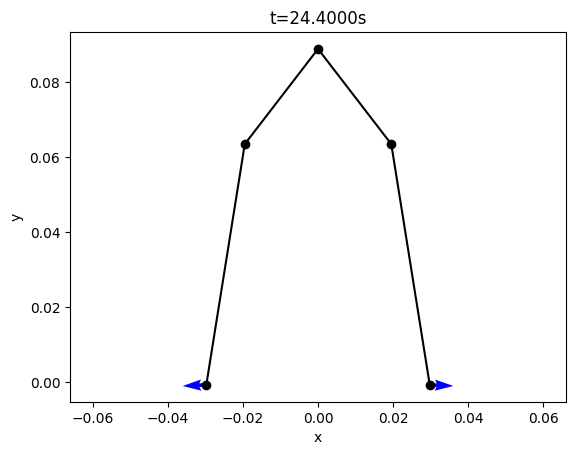

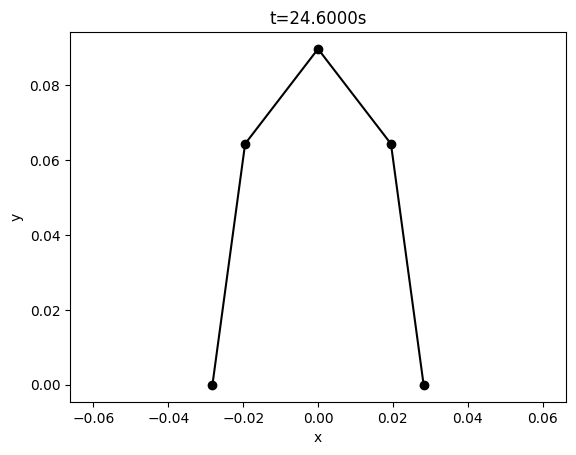

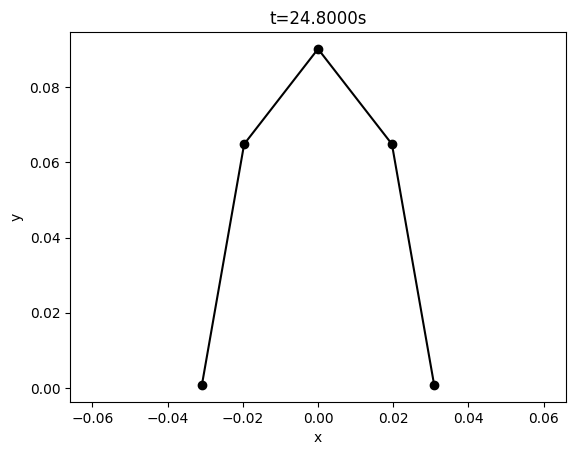

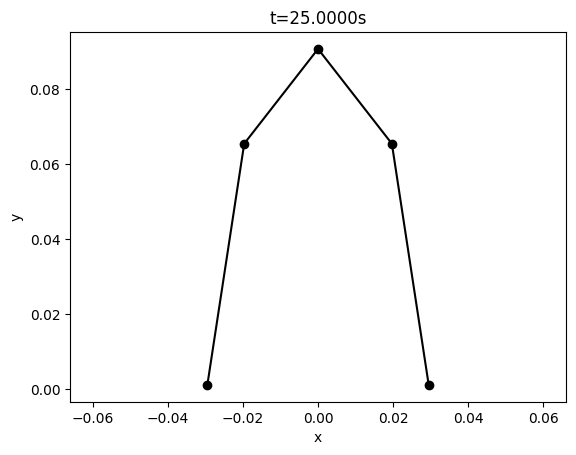

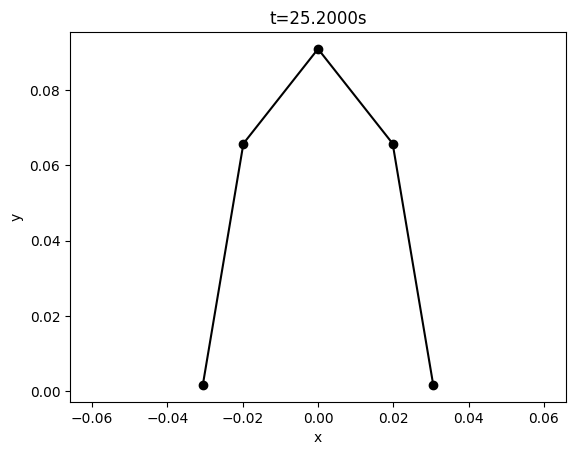

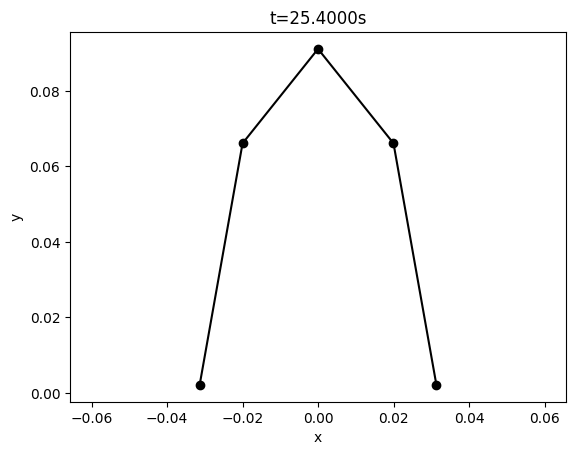

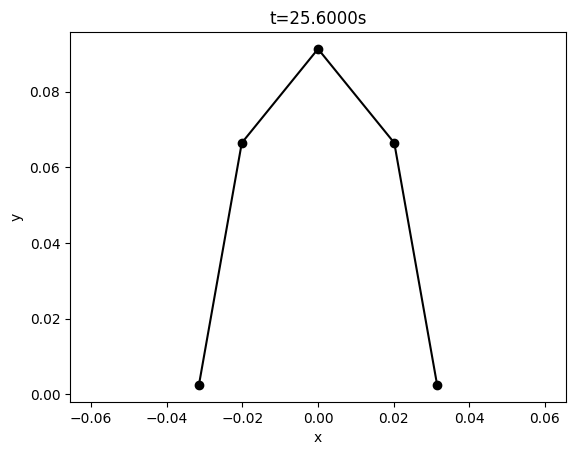

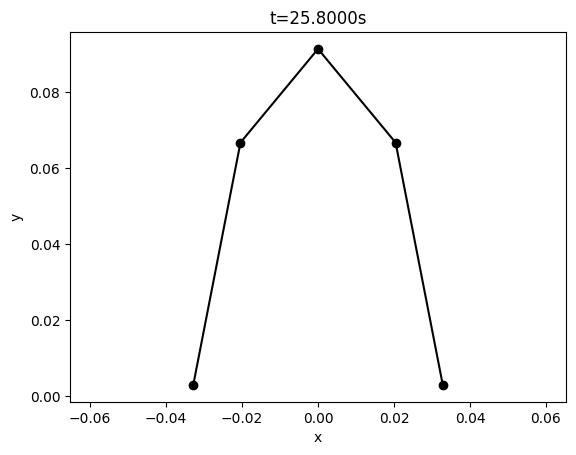

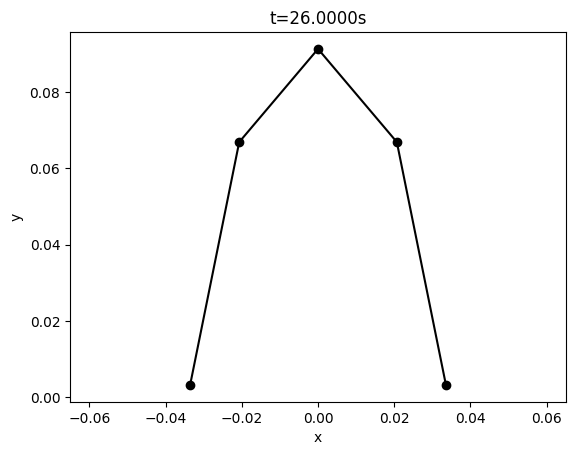

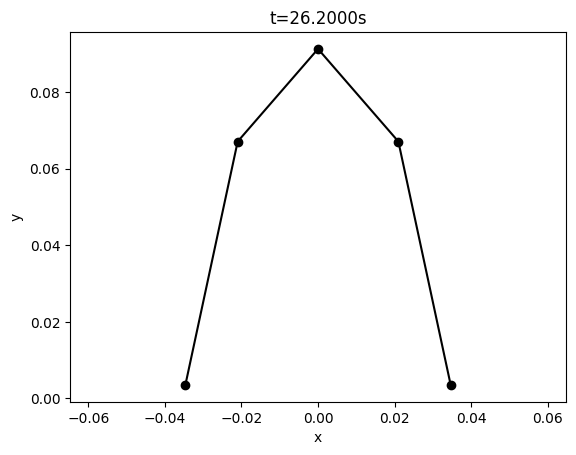

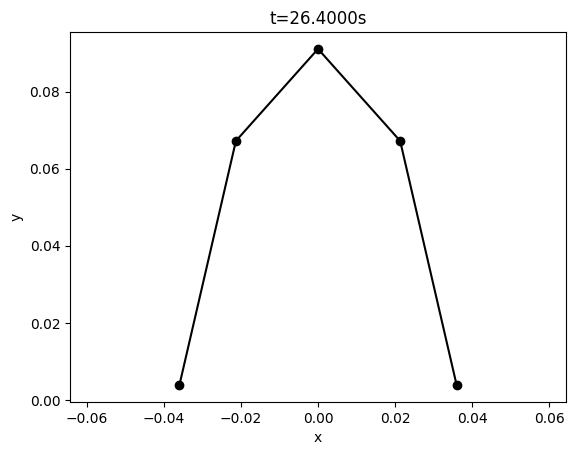

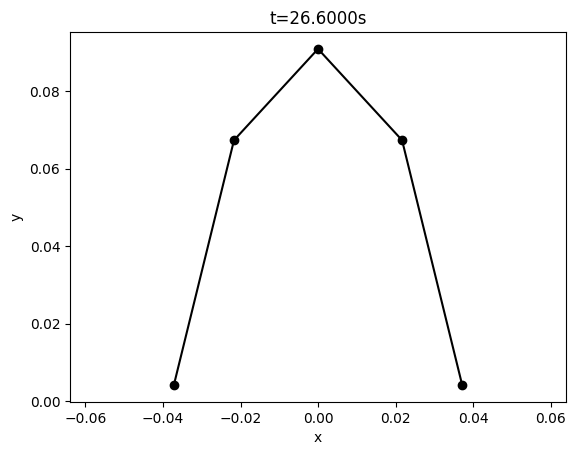

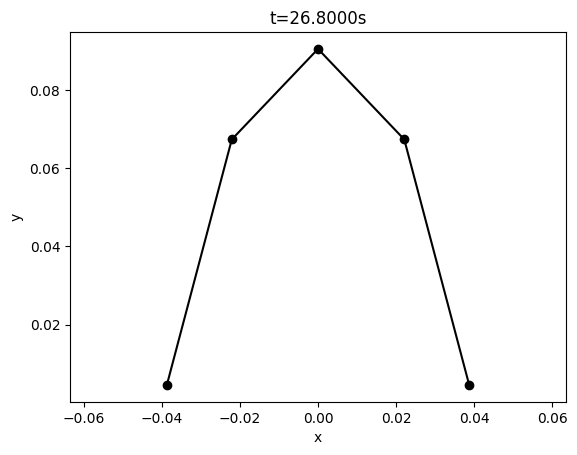

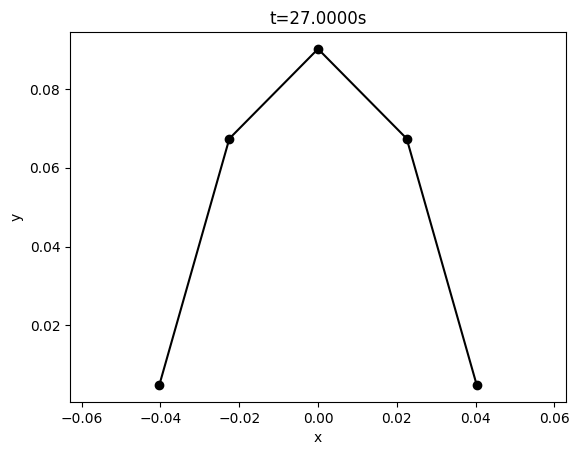

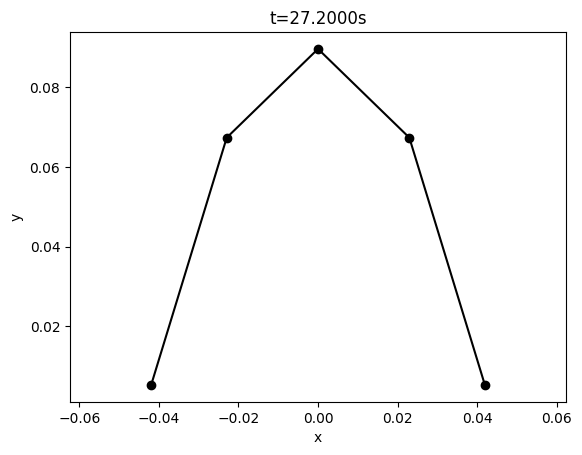

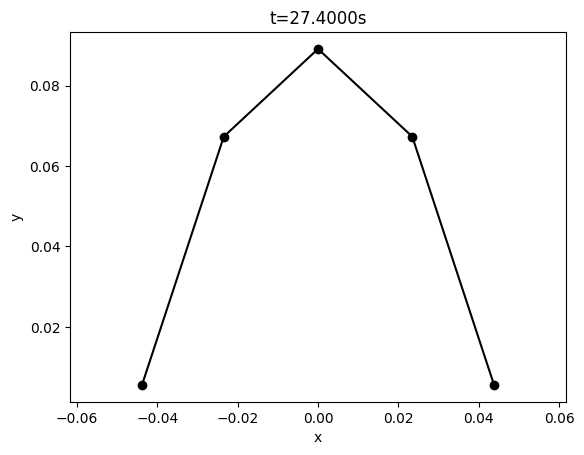

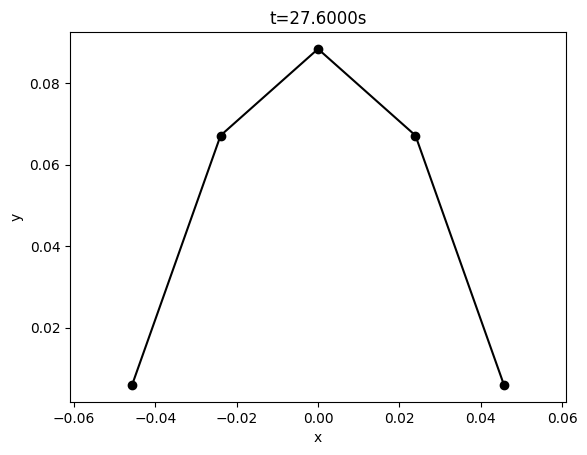

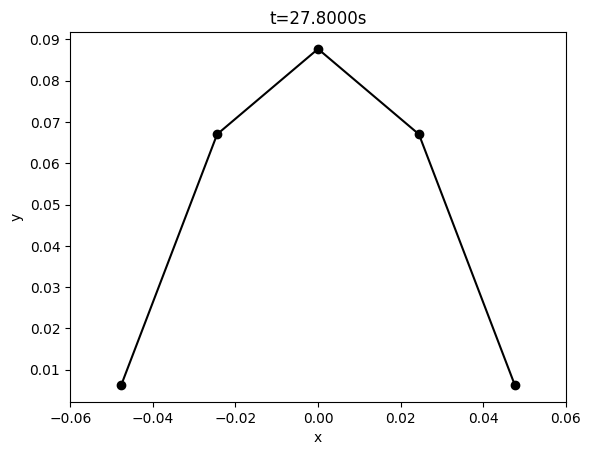

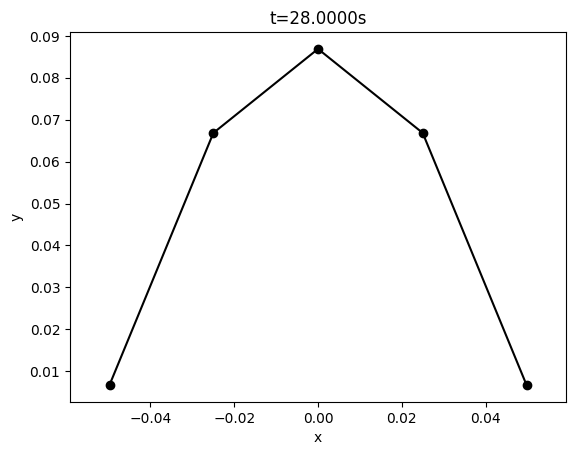

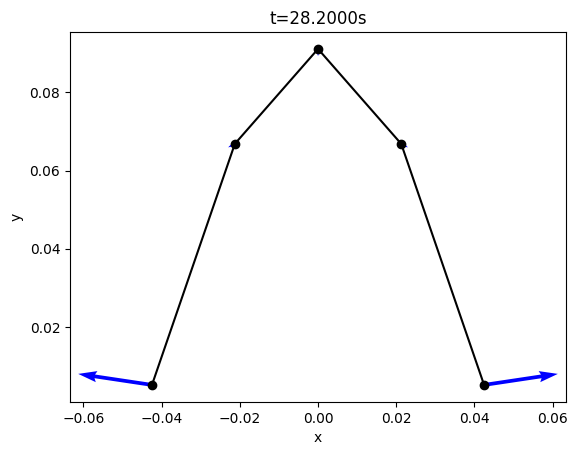

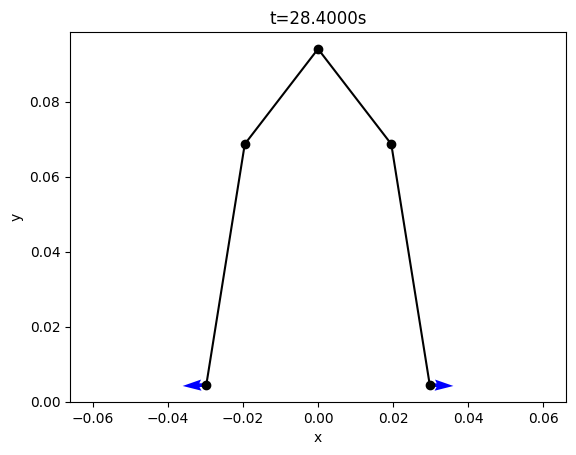

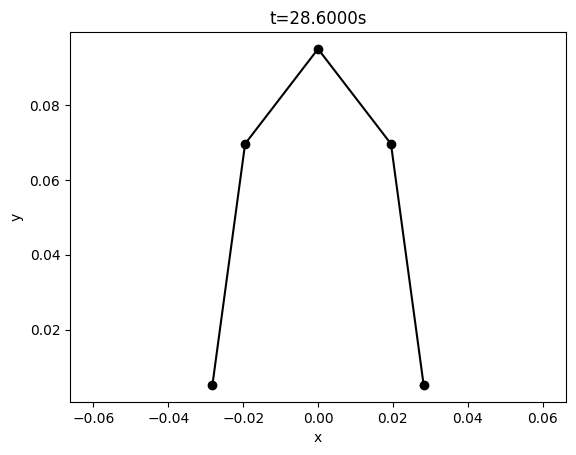

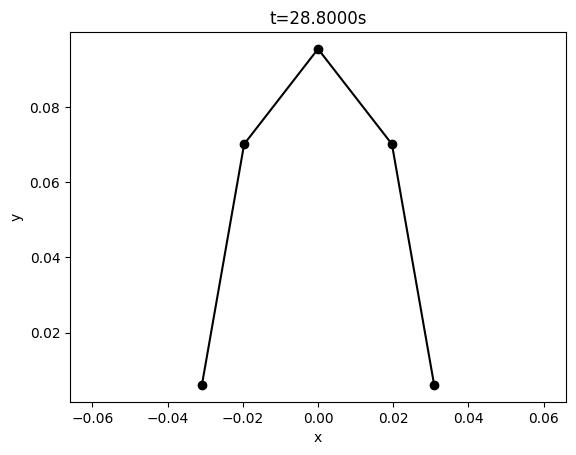

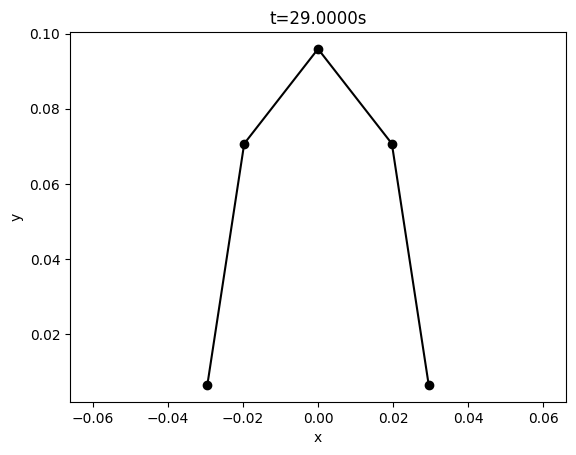

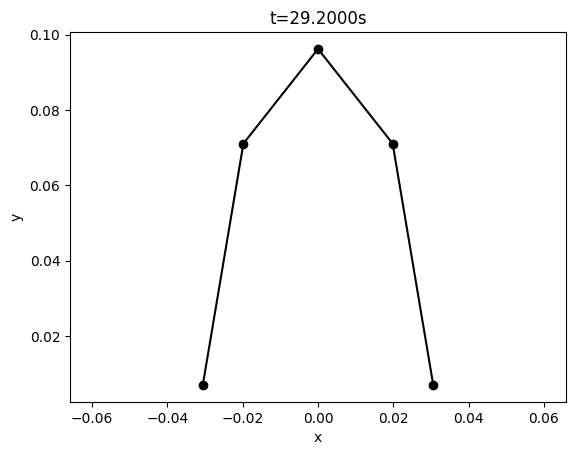

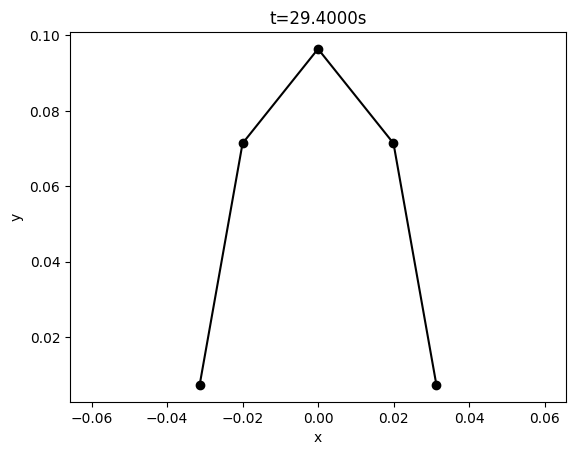

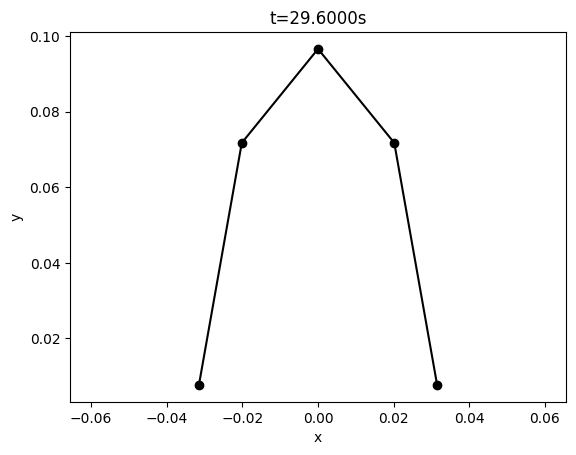

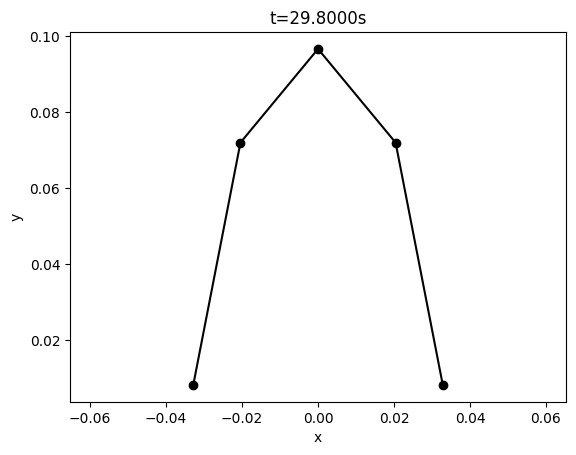

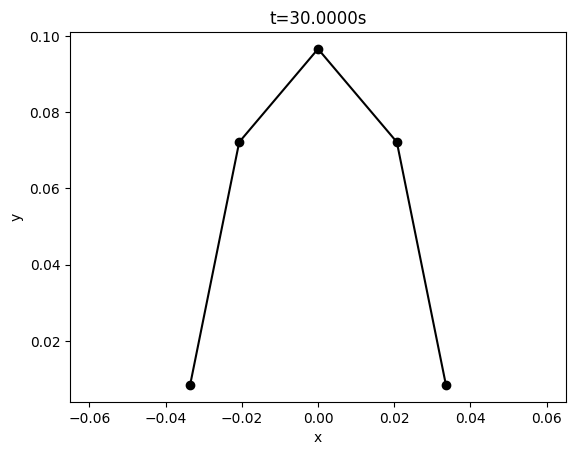

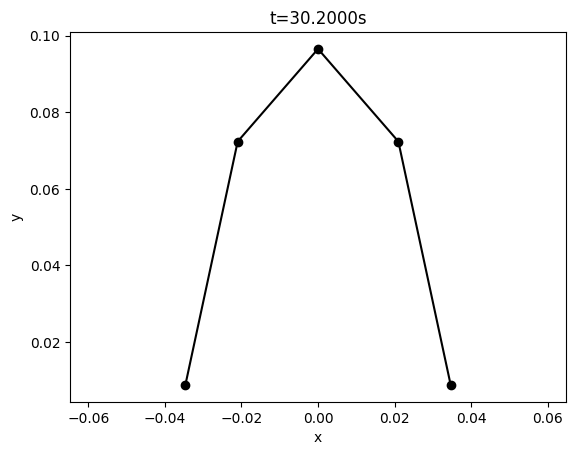

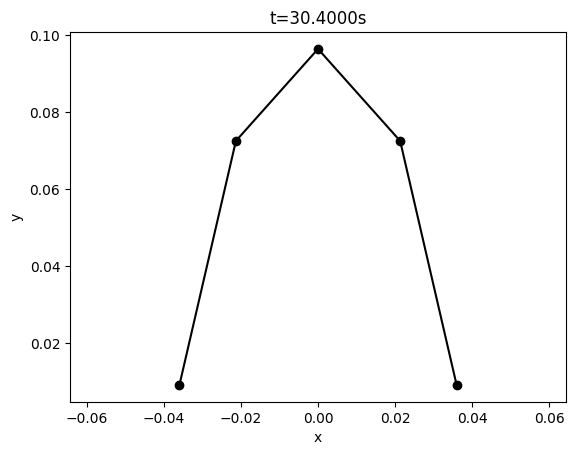

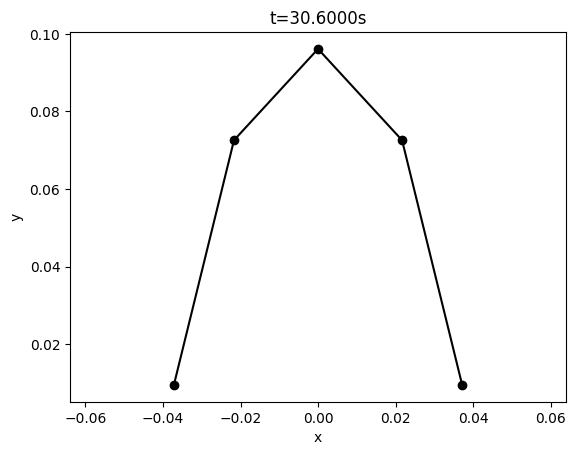

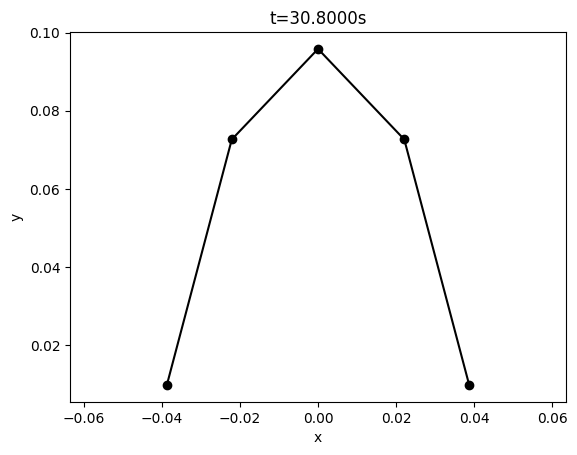

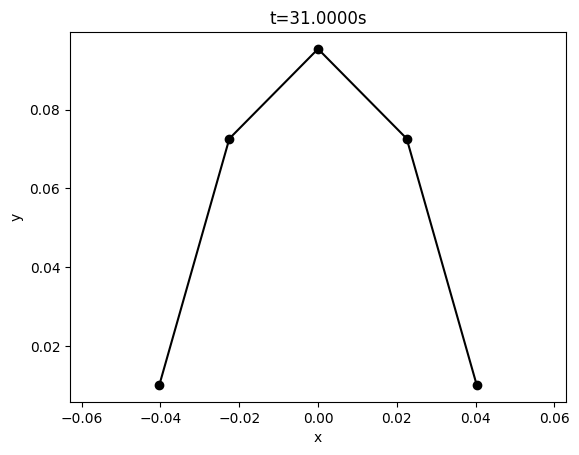

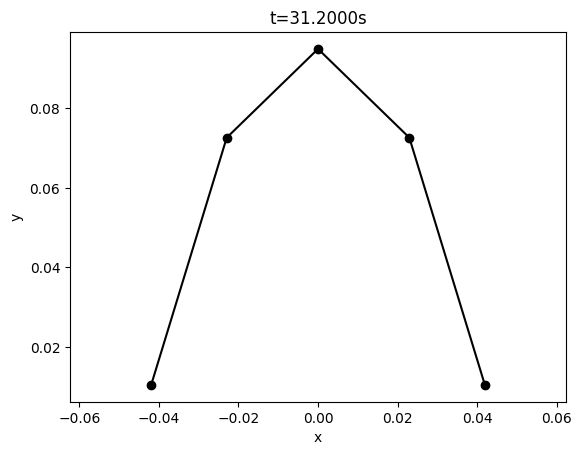

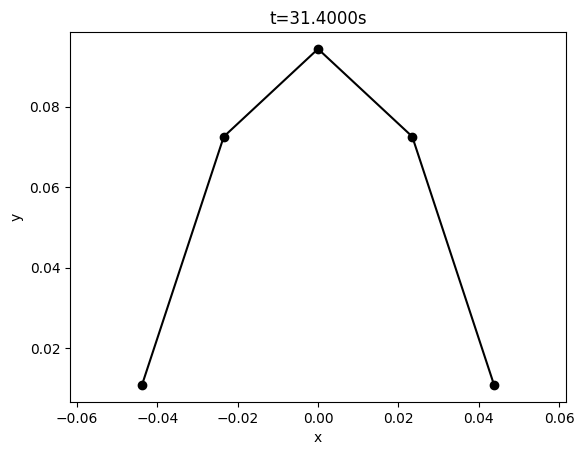

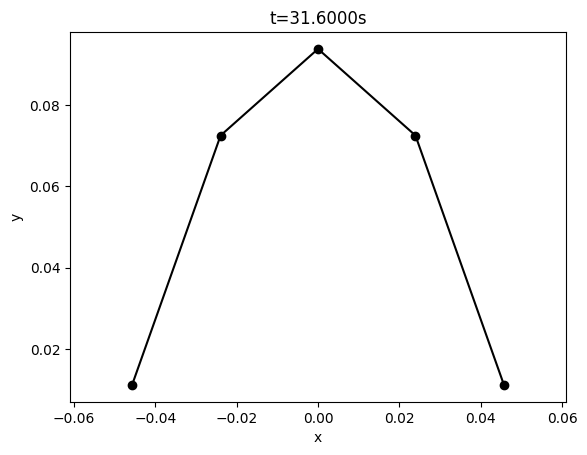

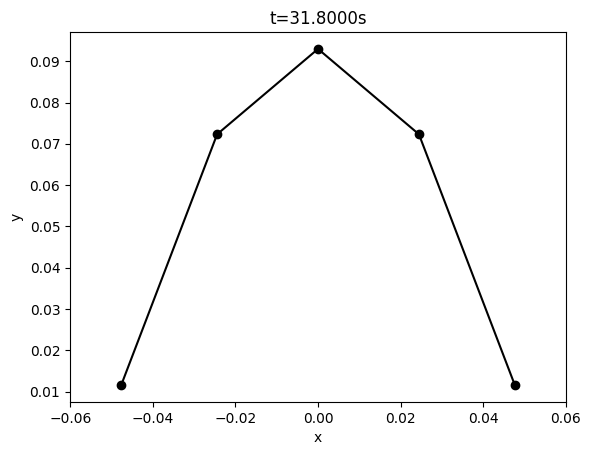

In [ ]:
totalTime = 32.0 # (seconds)
dt = 0.01 #  0.01
plotStep = 20 # Plot every 10 time steps

# Added Mass Coeficient
k_a = 0.001
k_w = 0.08

q_history = []

tol = 1e-6
maximum_iter = 5000
EI = 0.01
EA = 30
C = np.eye(ndof)* 0.0001
deltaL = np.zeros(ne)

for k in range(ne):
  deltaL[k] = np.sqrt((q0[2*k]-q0[2*k+2])**2 + (q0[2*k+1]-q0[2*k+3])**2)

free_index = np.arange(len(q0))

# Number of steps
Nsteps = round( totalTime / dt )
ctime = 0 # Current time
all_pos = np.zeros(Nsteps)
all_x_first = np.zeros(Nsteps)
all_x_last = np.zeros(Nsteps)
all_vx_first = np.zeros(Nsteps)
all_vx_last = np.zeros(Nsteps)
all_vy_first = np.zeros(Nsteps)
all_vy_last = np.zeros(Nsteps)
all_q = np.zeros((Nsteps, ndof))
all_f = np.zeros((Nsteps, ndof))

all_kappas = np.zeros(Nsteps)

# Loop over the time steps
for timeStep in range(1,Nsteps):
  # kappas = time_variant_curvature(ctime, natural_kappas,delta_top, delta_bottom, period, delay, hold_time, decay_time_constant)
  kappas = natural_kappas.copy()
  kappas[1] = natural_kappas[1] - kappa_time(ctime, 0.363636)

  F_thrust = np.zeros(len(q0))
  J_thrust = np.zeros((len(q0), len(q0)))

  q_new, error, forces = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W, C,
                        deltaL, kappas, free_index, Ct, Cp)

  if error < 0:
    print('Could not converge.')
    break

  u_new = (q_new - q0) / dt # New velocity

  mid_idx = nv // 2
  all_pos[timeStep] = q0[2*mid_idx + 1]
  all_x_first[timeStep] = q0[0]  # First node x-position
  all_x_last[timeStep] = q0[-2]   # Last node x-position
  all_vx_first[timeStep] = u_new[0]  # First node x-velocity
  all_vx_last[timeStep] = u_new[-2]   # Last node x-velocity
  all_vy_first[timeStep] = u_new[1]  # First node y-velocity
  all_vy_last[timeStep] = u_new[-1]  # Last node y-velocity
  all_kappas[timeStep] = kappas[1]
  all_q[timeStep] = q_new
  all_f[timeStep] = forces

  ctime += dt # Update current time

  q0 = q_new.copy() # New position becomes old position
  u0 = u_new.copy() # New velocity becomes old velocity

  # Plot
  if timeStep % plotStep == 0:
    x_arr = q_new[::2] # q[0], q[2], q[4]
    y_arr = q_new[1::2] # q[1], q[3], q[5]

    # plt.figure(1)
    # plt.clf() # Clear current figure
    plt.plot(x_arr, y_arr, 'ko-')
    plt.quiver(x_arr, y_arr, forces[::2], forces[1::2], color='blue', scale=2.5)
    plt.title(f't={ctime:.4f}s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.show()

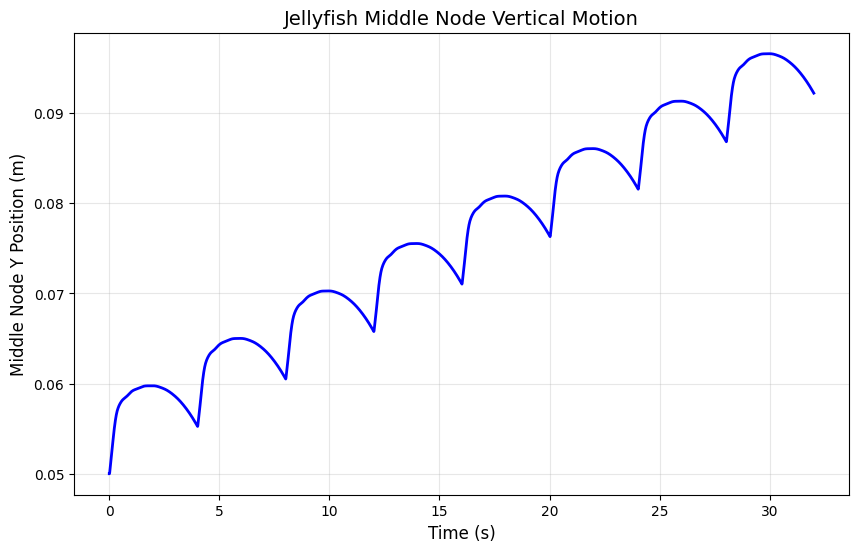

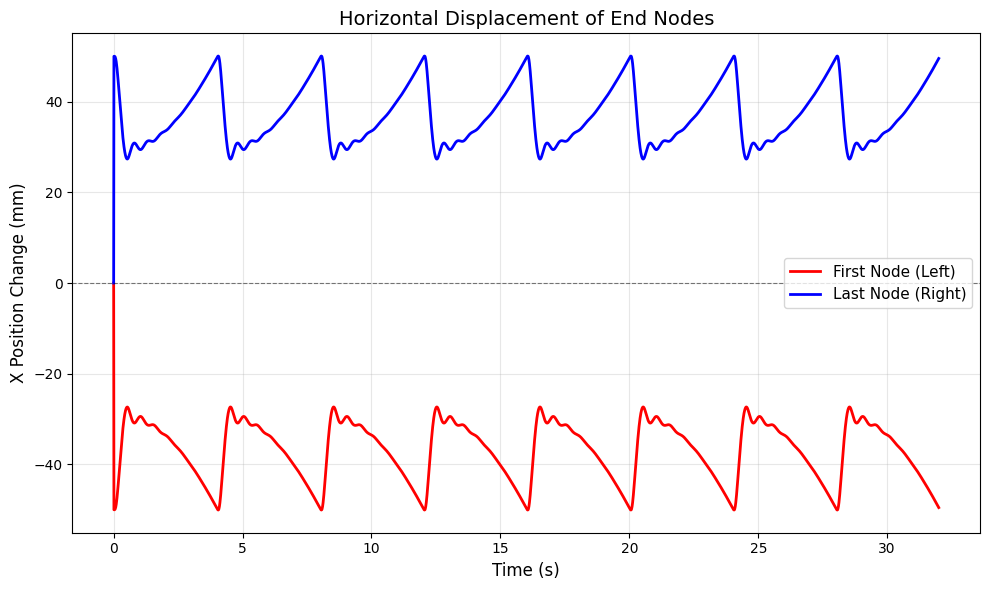

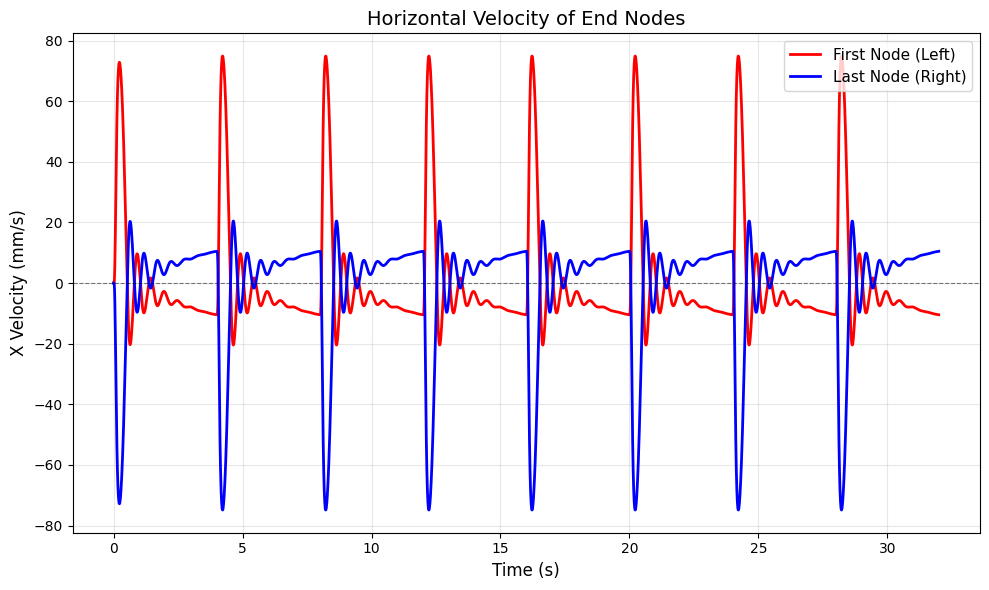

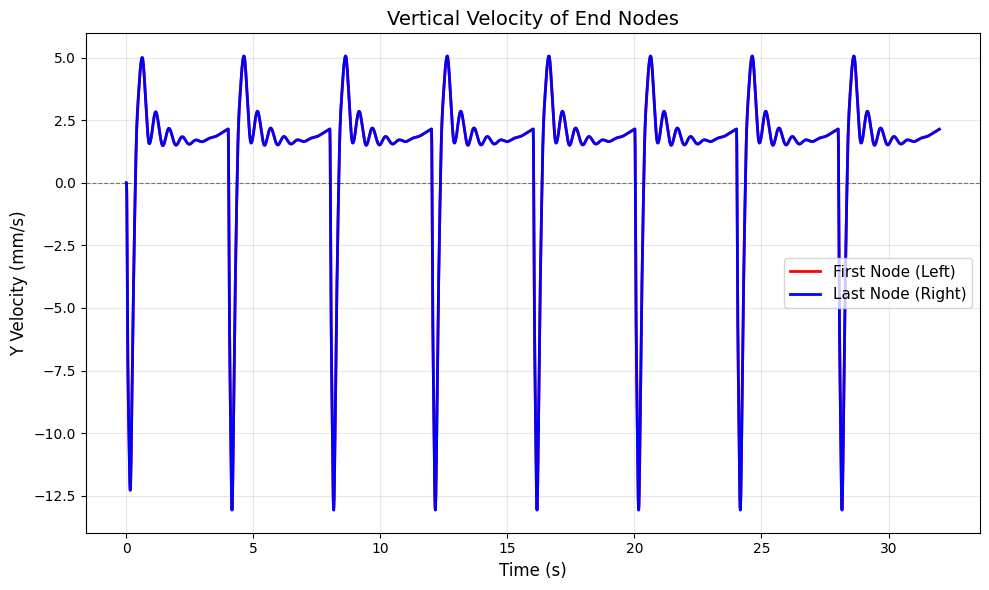

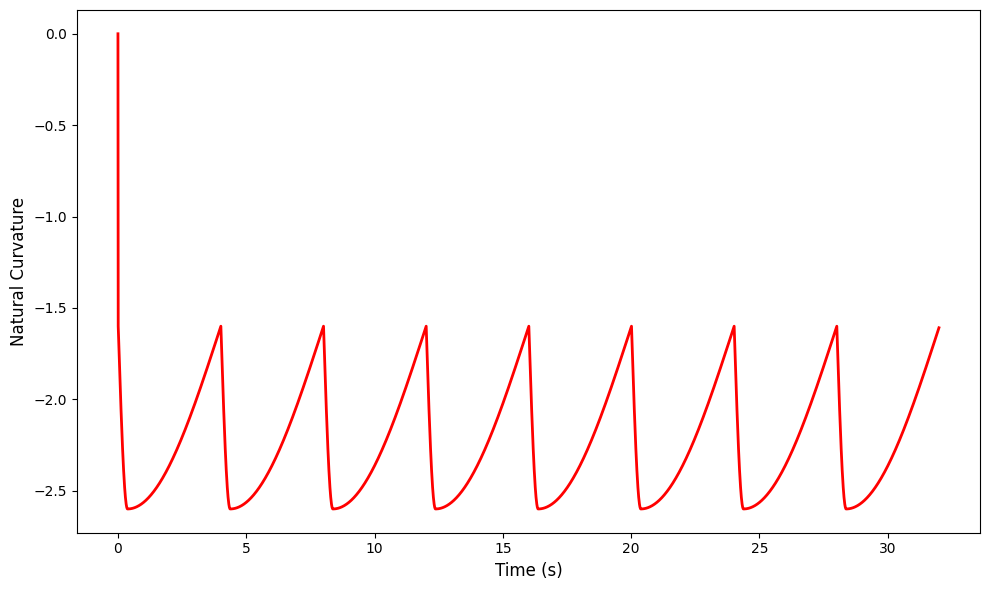

In [ ]:
# Plot the middle node information as a function of time

t_arr = np.linspace(0, totalTime, Nsteps)

plt.figure(2, figsize=(10, 6))
plt.plot(t_arr[1:], all_pos[1:], 'b-', linewidth=2)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Middle Node Y Position (m)', fontsize=12)
plt.title('Jellyfish Middle Node Vertical Motion', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(3, figsize=(10, 6))
x_first_initial = all_x_first[0]
x_last_initial = all_x_last[0]
delta_x_first = all_x_first - x_first_initial
delta_x_last = all_x_last - x_last_initial
plt.plot(t_arr, delta_x_first * 1000, 'r-', linewidth=2, label='First Node (Left)')
plt.plot(t_arr, delta_x_last * 1000, 'b-', linewidth=2, label='Last Node (Right)')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('X Position Change (mm)', fontsize=12)
plt.title('Horizontal Displacement of End Nodes', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(4, figsize=(10, 6))
plt.plot(t_arr, all_vx_first * 1000, 'r-', linewidth=2, label='First Node (Left)')
plt.plot(t_arr, all_vx_last * 1000, 'b-', linewidth=2, label='Last Node (Right)')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('X Velocity (mm/s)', fontsize=12)
plt.title('Horizontal Velocity of End Nodes', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(5, figsize=(10, 6))
plt.plot(t_arr, all_vy_first * 1000, 'r-', linewidth=2, label='First Node (Left)')
plt.plot(t_arr, all_vy_last * 1000, 'b-', linewidth=2, label='Last Node (Right)')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Y Velocity (mm/s)', fontsize=12)
plt.title('Vertical Velocity of End Nodes', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(6, figsize=(10, 6))
plt.plot(t_arr, all_kappas, 'r-', linewidth=2, label='Curvature')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Natural Curvature', fontsize=12)
plt.tight_layout()
plt.show()

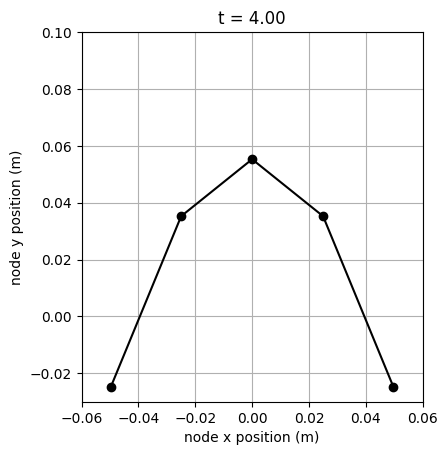

In [ ]:
fig, ax = plt.subplots()

nodes = ax.plot(all_q[400,::2], all_q[400,1::2], '-ko')[0]
quivers = ax.quiver(all_q[400,::2], all_q[400,1::2], all_f[400,::2], all_f[400,1::2], color='blue', scale=2.5)
ax.set(xlim=[-0.06, 0.06], ylim=[-0.03,0.1], xlabel='node x position (m)', ylabel='node y position (m)',title='t = 4.00 sec')
ax.grid(True)
ax.set_aspect('equal')

def update(frame):
    sto_frame = 5*(frame)+400 # starting at t=4s
    nodes.set_xdata(all_q[sto_frame,::2])
    nodes.set_ydata(all_q[sto_frame,1::2])
    quivers.set_offsets(np.array([all_q[sto_frame,::2], all_q[sto_frame,1::2]]).T)
    quivers.set_UVC(all_f[sto_frame,::2], all_f[sto_frame,1::2])
    ax.set_title(f't = {0.01*(sto_frame):.2f}')
    return nodes

ani = FuncAnimation(fig=fig, func=update, frames=559, interval=20)
# plt.show()
ani.save(filename="/anim.gif", writer="ffmpeg", fps=50)